# Imports

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List,Dict,Tuple

# 1. Analyse du jeu de données:

## Analyse

In [104]:
df_rh:pd.DataFrame=pd.read_csv("Data/RH_dataset.csv",delimiter=";")
df_rh.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [105]:
df_rh.isnull().sum()

Famille d'emploi                0
Dernière promotion (mois)       0
Dernière augmentation (mois)    0
Début de contrat (années)       0
Ancienneté groupe (années)      0
Etablissement                   0
Âge (années)                    0
Parent                          0
Niveau hiérarchique             0
Salaire (Euros)                 0
Statut marital                  0
Véhicule                        0
matricule                       0
label                           0
dtype: int64

On a pas de valuer nulle, analysons les types de données

In [106]:
df_rh.dtypes

Famille d'emploi                    str
Dernière promotion (mois)       float64
Dernière augmentation (mois)    float64
Début de contrat (années)       float64
Ancienneté groupe (années)      float64
Etablissement                     int64
Âge (années)                      int64
Parent                            int64
Niveau hiérarchique               int64
Salaire (Euros)                   int64
Statut marital                      str
Véhicule                          int64
matricule                         int64
label                             int64
dtype: object

In [107]:
df_rh.info()

<class 'pandas.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  str    
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  str    
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  label       

In [108]:
df_rh.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

On remarque une colone matricule qui représente le matricule de l'employé

In [109]:
df_rh.shape

(23857, 14)

## Analyse matricule

In [110]:
df_rh["matricule"].nunique()

2676

on a 2676 personnes dans le dataset donc comme il ya beaucoup plus de lignes on s'attends à ce que lorsqu'une personne a une évolution dans sa carrière, elle a une ligne pour chaque évolution. Donc on s'attends à ce que le matricule soit dupliqué. A vérifier.

In [111]:
#nombre de doublons dans matricule
df_rh["matricule"].duplicated().sum()


np.int64(21181)

In [112]:
df_rh["matricule"].value_counts()

matricule
32      15
1890    15
1847    15
1963    15
2642    15
        ..
1543     1
1558     1
2356     1
1571     1
1563     1
Name: count, Length: 2676, dtype: int64

beaucoup de matricule sont dupliqués, analysons les lignes du dataframe pour voir ce qui change quand le matricule est le même

In [113]:
# déterminer ce qui change dans les lignes du dataframe quand le matricule est le même
df_rh_doublons_matricule=df_rh[df_rh["matricule"].duplicated(keep=False)]
df_rh_doublons_matricule["matricule"].value_counts()

matricule
32      15
1890    15
1847    15
1963    15
2642    15
        ..
1547     2
1515     2
1544     2
2210     2
1318     2
Name: count, Length: 2490, dtype: int64

In [114]:
df_rh_doublons_matricule["matricule"].nunique()

2490

On a 2490 personnes sur les 2676 donc cela touche un grand nombre de personnes, analysons les lignes du dataframe pour voir ce qui change quand le matricule est le même

In [115]:
df_rh_doublons_matricule["matricule"].shape

(23671,)

In [116]:
#déterminons ce qui change dans les lignes du dataframe quand le matricule est le même
list_df_rh_doublons_matricule=[]
for mat in df_rh_doublons_matricule["matricule"].unique():
    list_df_rh_doublons_matricule.append(df_rh_doublons_matricule[df_rh_doublons_matricule["matricule"]==mat].sort_values(by="Ancienneté groupe (années)",ascending=True))

for i in range(4):
    display(list_df_rh_doublons_matricule[i])

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.91,0.97,27,30,1,1,3199,Marié(e),0,32,0
435,Production,11.280000,10.750000,1.18,1.20,27,30,1,1,3200,Marié(e),0,32,0
1735,Production,14.040000,13.590000,1.45,1.45,27,31,1,1,3200,Marié(e),0,32,0
3247,Production,16.920000,16.370001,1.70,1.70,27,32,1,1,3199,Marié(e),0,32,0
4799,Production,19.889999,19.340000,2.08,2.08,28,33,1,1,3199,Marié(e),0,32,0
6358,Etudes & Technique,2.350000,21.889999,2.27,2.38,27,34,1,1,3202,Marié(e),0,32,0
7967,Etudes & Technique,5.960000,0.960000,2.53,2.53,27,34,1,1,3560,Marié(e),0,32,0
9637,Etudes & Technique,8.710000,3.890000,2.77,2.77,27,34,1,1,3559,Marié(e),0,32,0
11353,Etudes & Technique,11.500000,6.770000,3.03,3.03,27,34,1,1,3560,Marié(e),0,32,0
13091,Etudes & Technique,14.770000,1.980000,3.25,3.31,27,35,1,1,3773,Marié(e),0,32,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
437,Production,37.970001,25.559999,15.020000,16.510000,7,46,1,2,3861,PACS,1,1890,0
1737,Production,40.820000,28.430000,15.210000,16.719999,7,47,1,2,3860,PACS,1,1890,0
3249,Production,43.750000,30.790001,15.420000,16.780001,7,48,1,2,3858,PACS,1,1890,0
5601,Production,46.869999,33.070000,15.720000,16.820000,7,48,1,2,3859,PACS,1,1890,0
7190,Matériel/Equipement,49.840000,2.060000,16.790001,17.440001,7,48,1,2,3960,Marié(e),1,1890,0
8834,Matériel/Equipement,52.630001,4.990000,17.049999,17.480000,7,49,1,2,3958,Marié(e),1,1890,0
10524,Matériel/Equipement,55.509998,7.910000,17.209999,17.670000,7,49,1,2,3954,Marié(e),1,1890,0
12258,Production,58.580002,10.920000,17.290001,17.990000,7,49,1,2,3951,Marié(e),1,1890,0
14032,Matériel/Equipement,61.770000,2.250000,17.889999,18.059999,7,50,1,2,4077,Marié(e),1,1890,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
438,Production,28.370001,25.240000,17.620001,18.000000,28,50,1,2,4326,PACS,1,1847,0
1738,Production,31.469999,27.980000,17.940001,18.070000,28,51,1,2,4327,PACS,1,1847,0
3250,Production,34.630001,30.309999,18.270000,18.370001,28,51,1,2,4327,PACS,1,1847,0
5602,Production,37.770000,32.619999,18.600000,18.670000,28,52,1,2,4327,PACS,1,1847,0
7191,Production,40.779999,34.849998,18.879999,18.969999,28,52,1,2,4327,PACS,1,1847,0
8835,Production,43.720001,2.510000,19.450001,19.450001,28,53,1,2,4461,PACS,1,1847,0
10525,Production,46.400002,5.170000,19.670000,19.750000,28,53,1,2,4458,PACS,1,1847,0
12259,Production,49.020000,7.630000,19.780001,20.049999,28,53,1,2,4454,PACS,1,1847,0
14033,Production,52.459999,2.490000,20.400000,20.400000,28,53,1,2,4553,PACS,1,1847,0


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
3,Production,5.24,5.10,1.02,1.75,27,24,0,1,2641,Célibataire,0,2619,1
439,Production,7.99,7.86,1.29,1.92,27,25,0,1,2640,Célibataire,0,2619,1


Ok on voit que les colones qui sont la famille d'emploi (rarement) ce qui indique un changement de poste (à vérifier si il y a des changements qui arrivent plus souvent que d'autres). Ce qui change toujours c'est l'ancienneté groupe (annnée) qui indique le nombre d'annnée que la personne a passé dans l'entreprise. On remarque que le début de contrat augmente aussi en permanence on note qu'il y a souvent un écart de 0.6 entre le début de contrat et l'ancienneté groupe (années) ce qui indique surement une période d'essai de 6 mois (il serait intéressant de voir quelqu'un avec une date de contrat qui repart de 0 pour analyser si ça existe). On a aussi la dernière promotion qui est donc fortement lié à l'augmentation de salaire celle ci fluctue beaucoup et semble assez important pour prédire le label. On a établissement qui peut changer il faudrait voir si c'est lié avec les augmentation ou les changements de postes. On pourrait lier les établissement avec les familles d'emploi pour voir si il y a des établissements qui sont plus propices à certaines familles d'emploi. Le statut marital change aussi et on peut voir si cela a un impact sur les salaires et la démission. Et les autres colones changent aussi. On peut en conclure que cela représente bel et bien l'évolution des personnes dans l'entreprise.



## Retour analyse gloabale


In [117]:
df_rh.describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,0.506853,1361.255858,0.031647
std,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,0.500299,794.183153,0.175062
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.000000
25%,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,0.000000,655.000000,0.000000
50%,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,1.000000,1371.000000,0.000000
75%,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,1.000000,2072.000000,0.000000
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,1.000000


On remarque que l'on a des données de types différents: int, float et string. Nous allons devoir faire du prétraitement pour pouvoir utiliser ces données dans un modèle de machine learning. De plus les données numérique ne sont pas à la même échelle, il faudra donc les normaliser. Enfin, il y a des données catégorielles qui devront être encodées.

In [118]:

str_columns: List[str] = df_rh.select_dtypes(include=['str']).columns.tolist()
str_columns

["Famille d'emploi", 'Statut marital']

Regardons la distributions des données dans les différentes colones.

In [119]:
numeric_columns: List[str] = df_rh.columns.difference(str_columns).tolist()
numeric_columns

['Ancienneté groupe (années)',
 'Dernière augmentation (mois)',
 'Dernière promotion (mois)',
 'Début de contrat (années)',
 'Etablissement',
 'Niveau hiérarchique',
 'Parent',
 'Salaire (Euros)',
 'Véhicule',
 'label',
 'matricule',
 'Âge (années)']

regardons la plage de valeur de chaque colone numérique pour voir si on doit les normaliser ou pas.

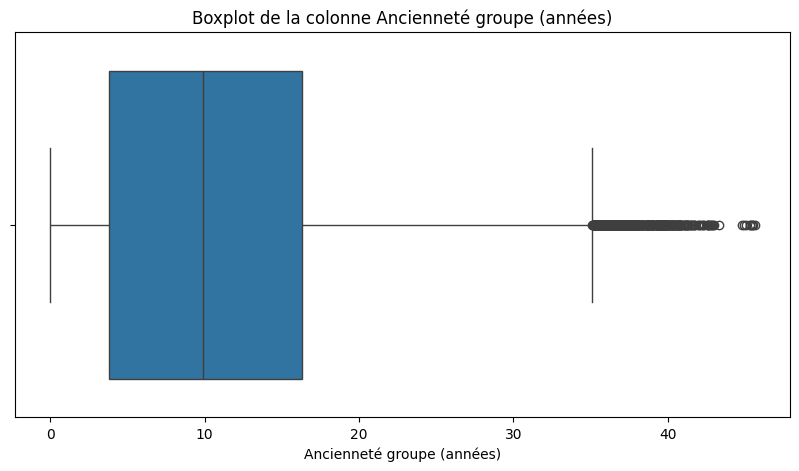

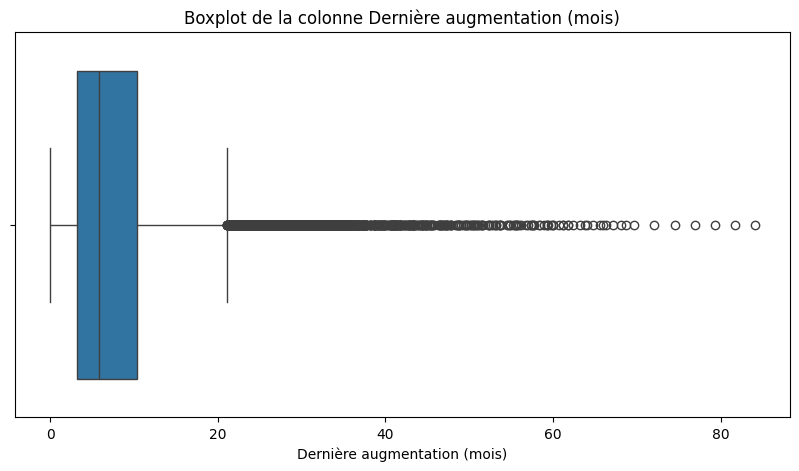

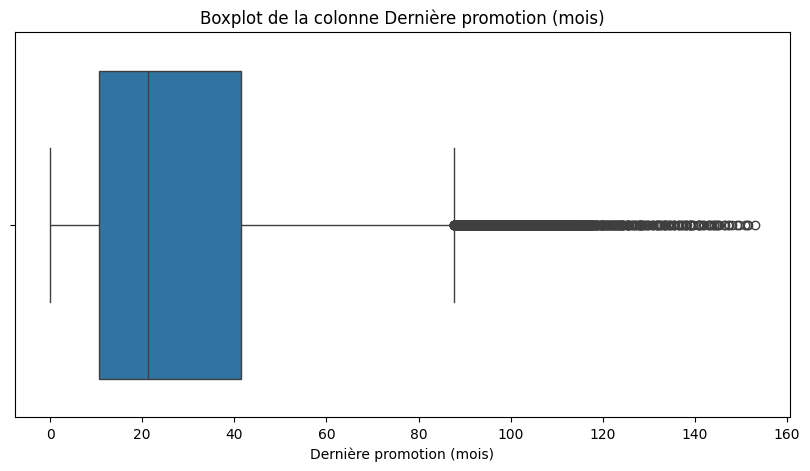

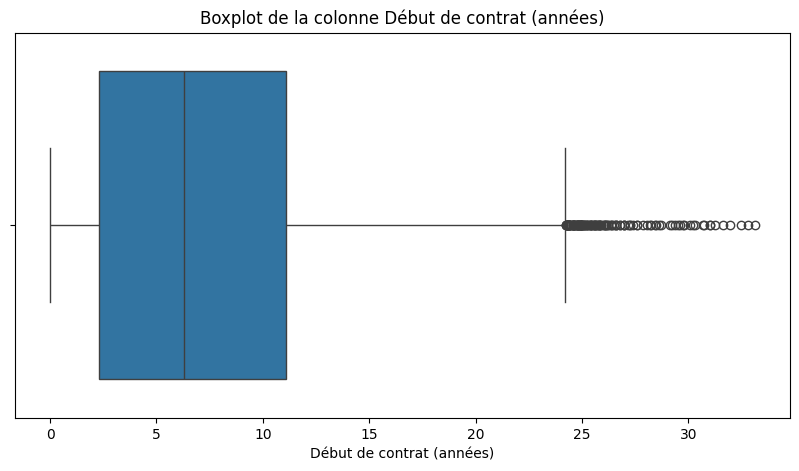

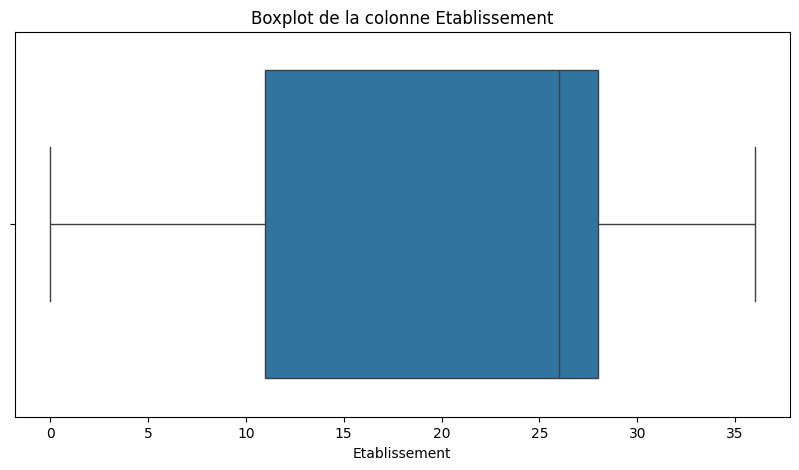

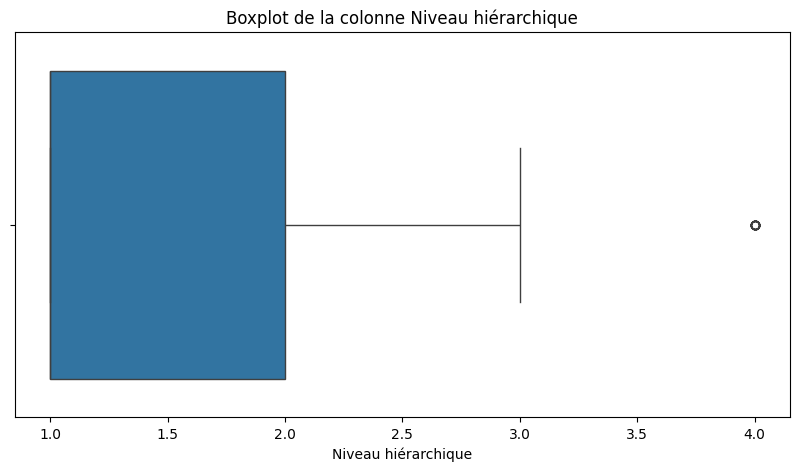

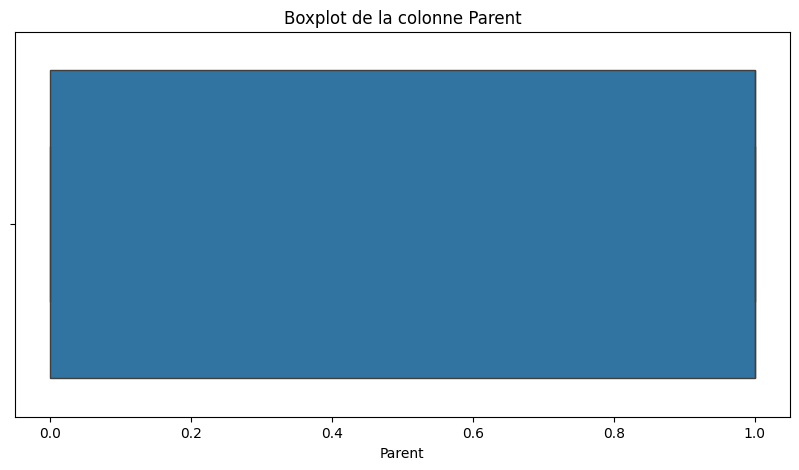

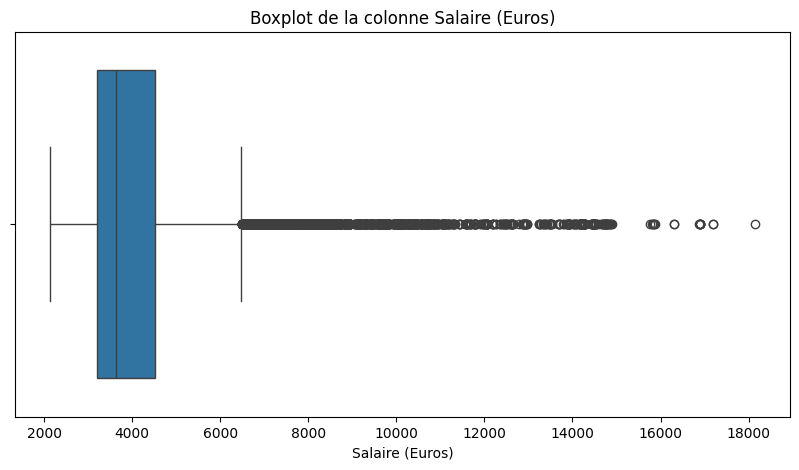

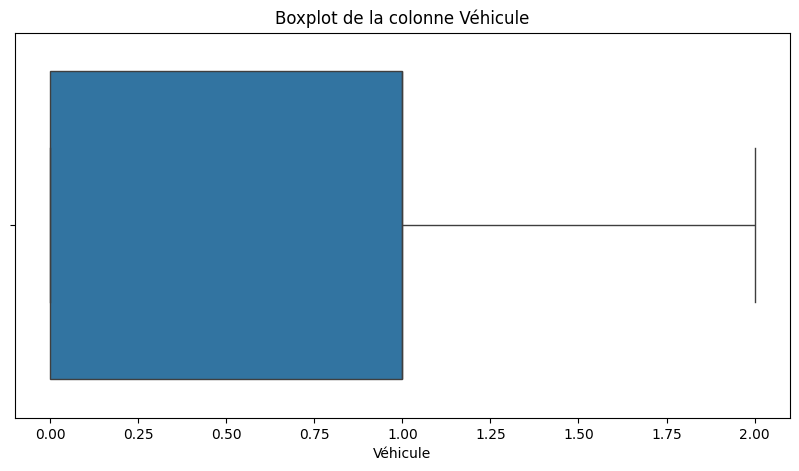

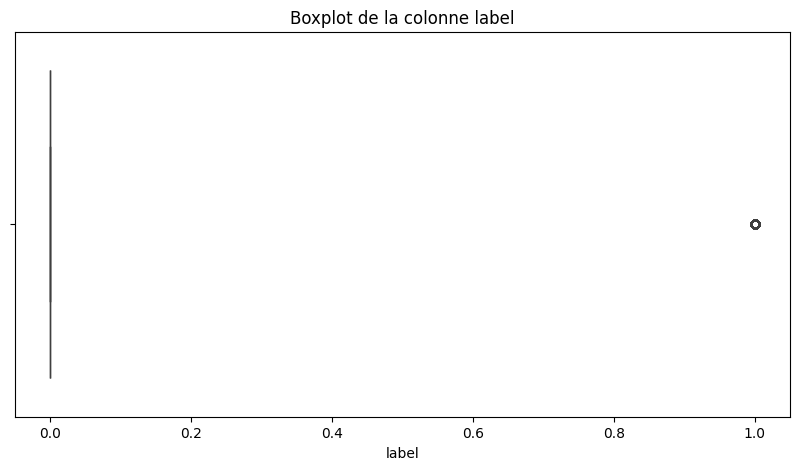

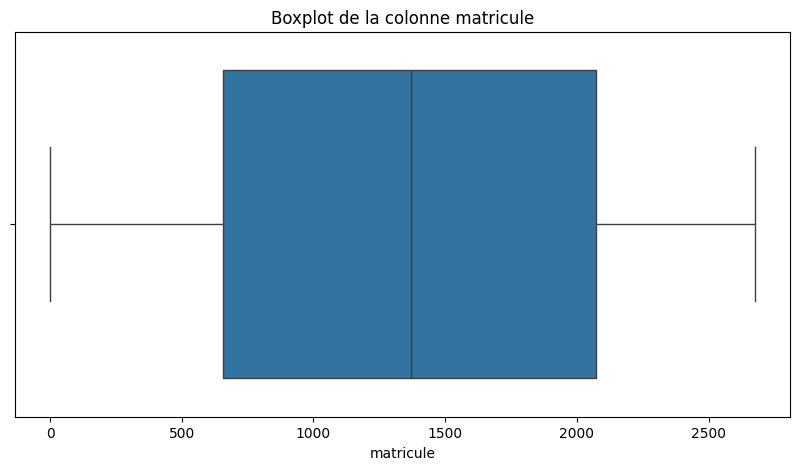

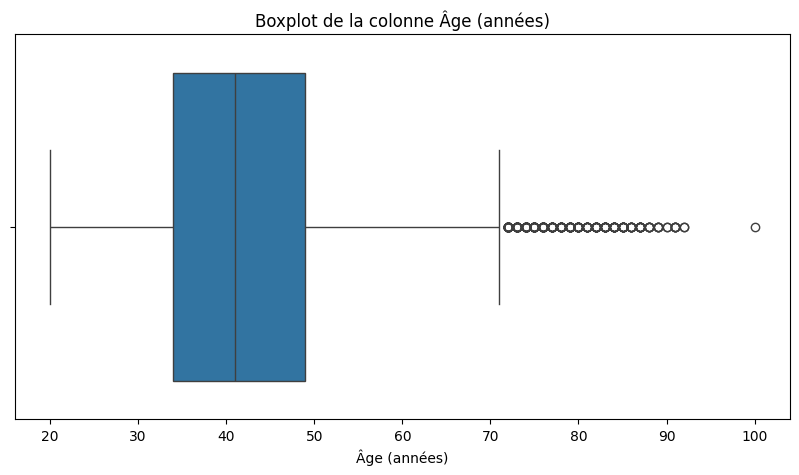

In [120]:
for col in numeric_columns:
    #boxplot
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_rh, x=col)
    plt.title(f"Boxplot de la colonne {col}")
    plt.show()


On remarque quelques outliers

In [121]:
dictionary_min_max_columns:Dict[str,Tuple[int,int]] = {}

for col in numeric_columns:
    print("la valeur max dela colone",col,"est de",df_rh[col].max()
          ,"et la valeur min est de",df_rh[col].min())
    dictionary_min_max_columns[col]=(df_rh[col].min(),df_rh[col].max())
    
    

la valeur max dela colone Ancienneté groupe (années) est de 45.619998931884766 et la valeur min est de 0.0
la valeur max dela colone Dernière augmentation (mois) est de 84.05000305175781 et la valeur min est de 0.0
la valeur max dela colone Dernière promotion (mois) est de 152.97000122070312 et la valeur min est de 0.0
la valeur max dela colone Début de contrat (années) est de 33.119998931884766 et la valeur min est de 0.0
la valeur max dela colone Etablissement est de 36 et la valeur min est de 0
la valeur max dela colone Niveau hiérarchique est de 4 et la valeur min est de 1
la valeur max dela colone Parent est de 1 et la valeur min est de 0
la valeur max dela colone Salaire (Euros) est de 18137 et la valeur min est de 2134
la valeur max dela colone Véhicule est de 2 et la valeur min est de 0
la valeur max dela colone label est de 1 et la valeur min est de 0
la valeur max dela colone matricule est de 2675 et la valeur min est de 0
la valeur max dela colone Âge (années) est de 100 et 

In [122]:
print(dictionary_min_max_columns)

{'Ancienneté groupe (années)': (np.float64(0.0), np.float64(45.619998931884766)), 'Dernière augmentation (mois)': (np.float64(0.0), np.float64(84.05000305175781)), 'Dernière promotion (mois)': (np.float64(0.0), np.float64(152.97000122070312)), 'Début de contrat (années)': (np.float64(0.0), np.float64(33.119998931884766)), 'Etablissement': (np.int64(0), np.int64(36)), 'Niveau hiérarchique': (np.int64(1), np.int64(4)), 'Parent': (np.int64(0), np.int64(1)), 'Salaire (Euros)': (np.int64(2134), np.int64(18137)), 'Véhicule': (np.int64(0), np.int64(2)), 'label': (np.int64(0), np.int64(1)), 'matricule': (np.int64(0), np.int64(2675)), 'Âge (années)': (np.int64(20), np.int64(100))}


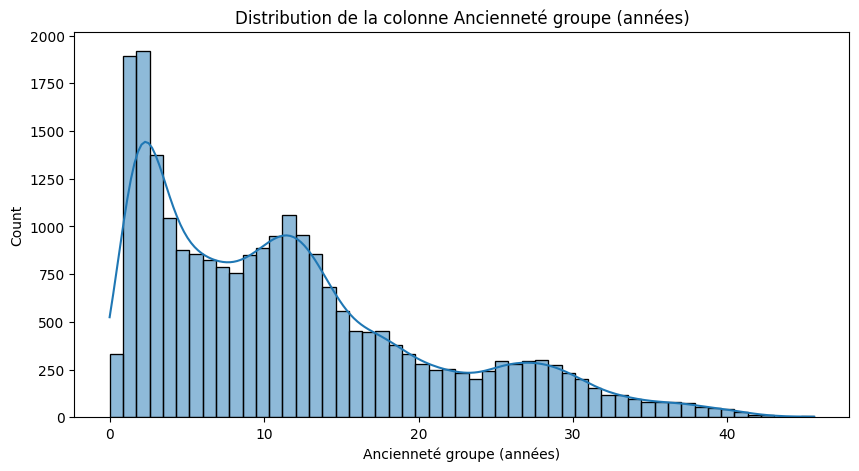

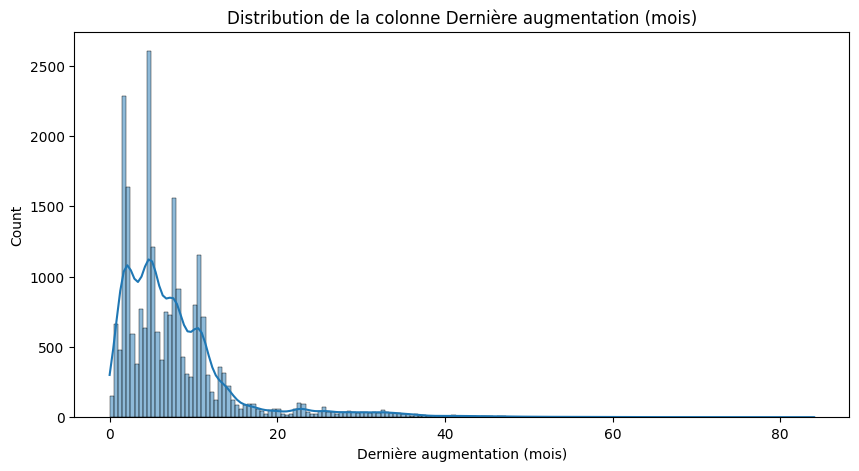

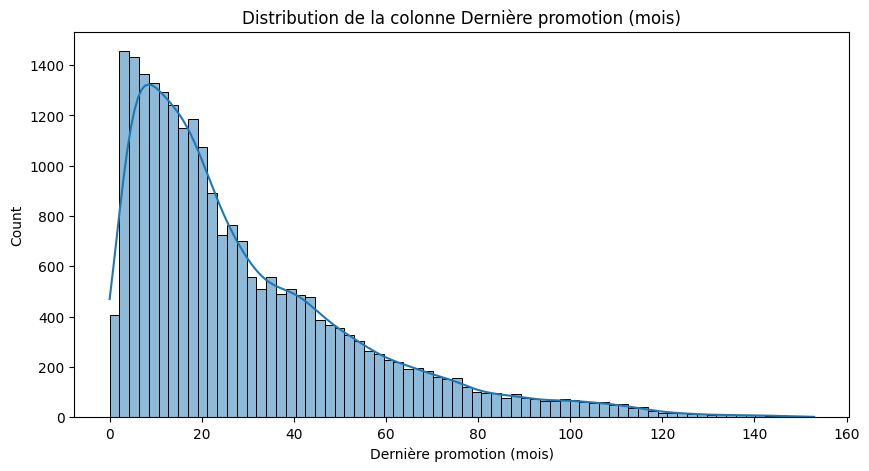

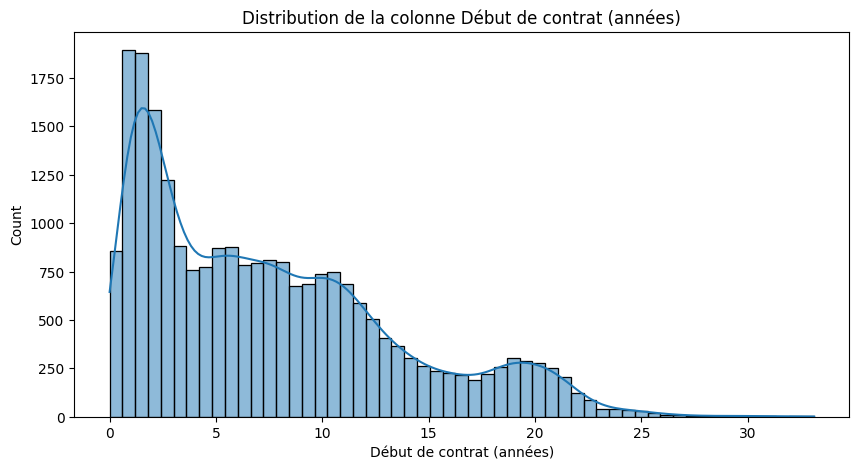

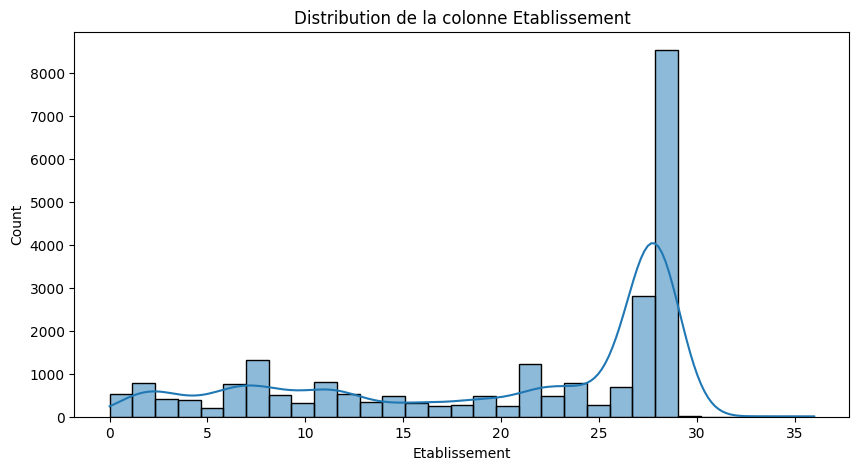

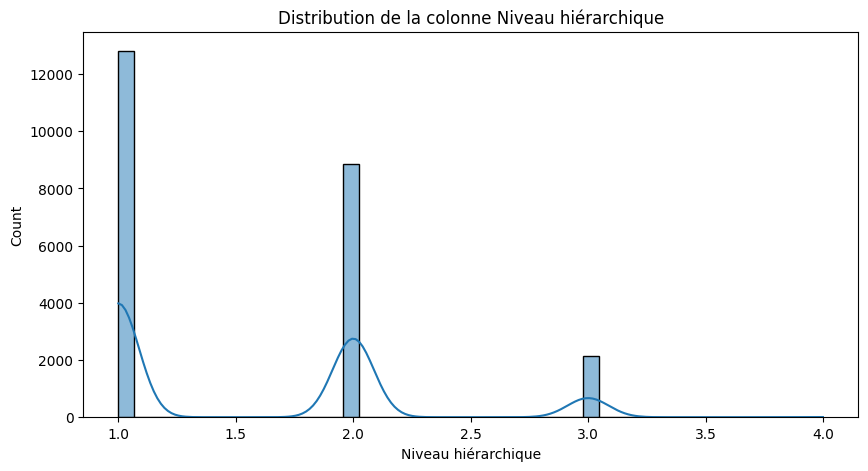

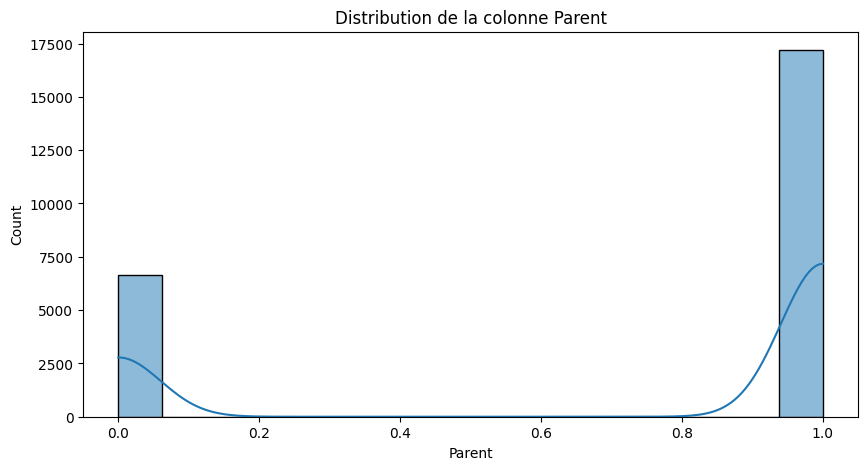

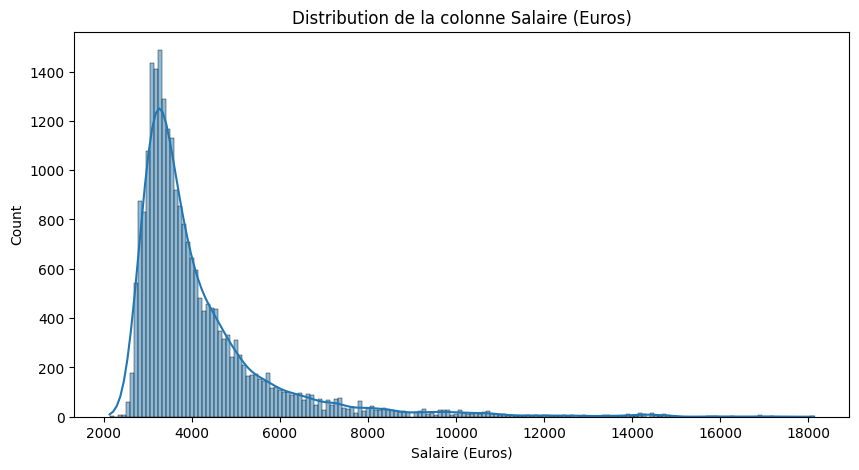

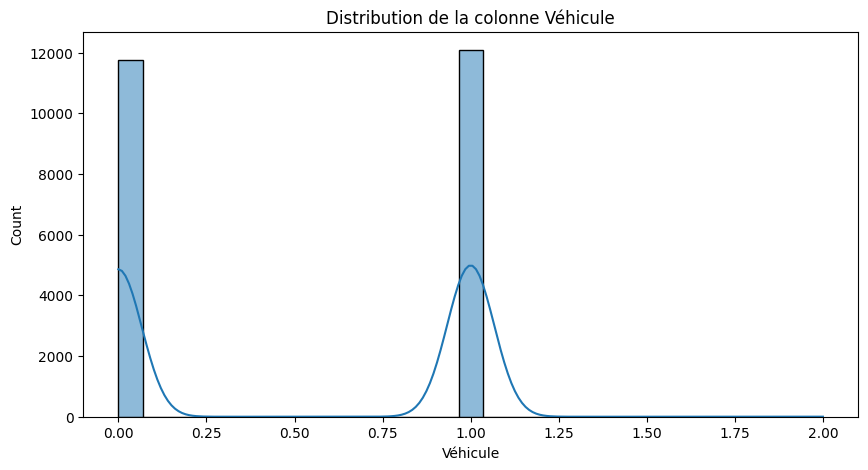

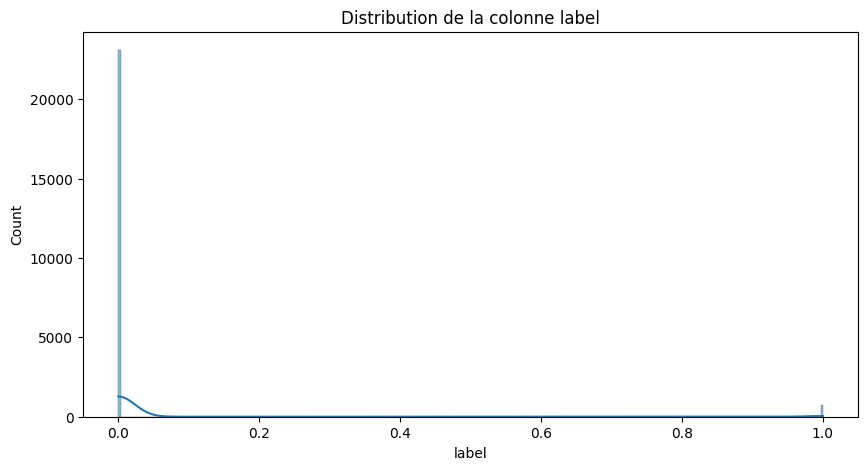

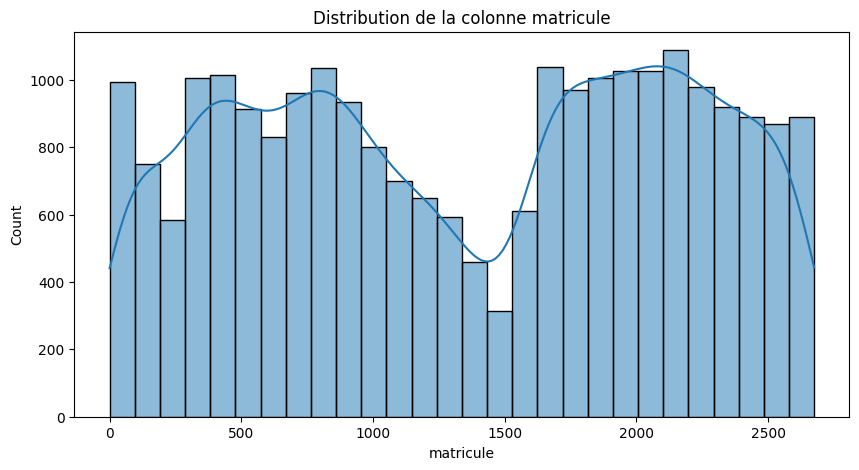

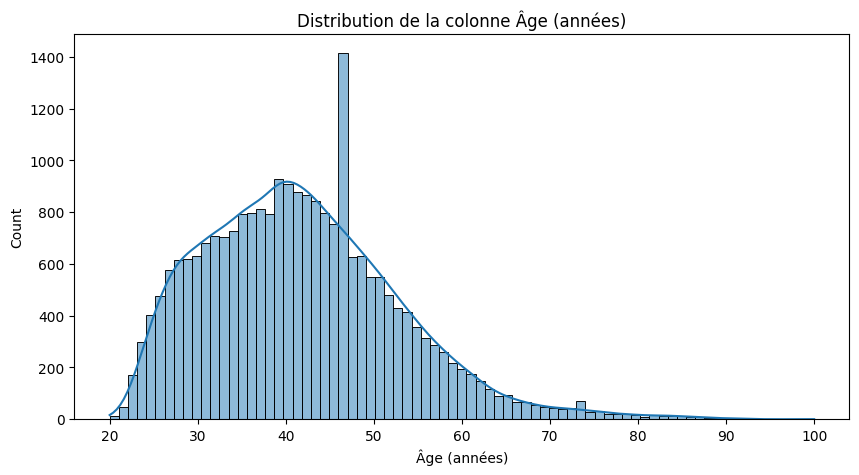

In [123]:
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col], kde=True)
    plt.title(f"Distribution de la colonne {col}")
    plt.show()

On remarque que certaines colones sont continues et d'autres sont didcrètes. Les colones discrètes sont:
- Etablissement
- label (forcément)
- véhicule
- Parent
- Niveau hierarchique  

donc:

In [124]:
discrete_columns: List[str] = ['Etablissement', 'label', 'Véhicule', 'Parent', 'Niveau hiérarchique']
df_rh[discrete_columns].nunique()

Etablissement          35
label                   2
Véhicule                3
Parent                  2
Niveau hiérarchique     4
dtype: int64

In [125]:
continus_columns:List[str] = [col for col in numeric_columns if col not in discrete_columns]
continus_columns

['Ancienneté groupe (années)',
 'Dernière augmentation (mois)',
 'Dernière promotion (mois)',
 'Début de contrat (années)',
 'Salaire (Euros)',
 'matricule',
 'Âge (années)']

Regardons les deux types de colones séparément:

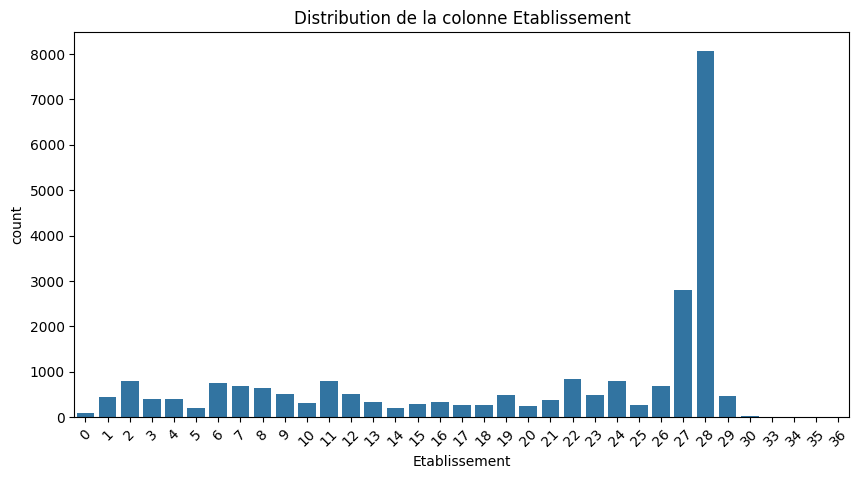

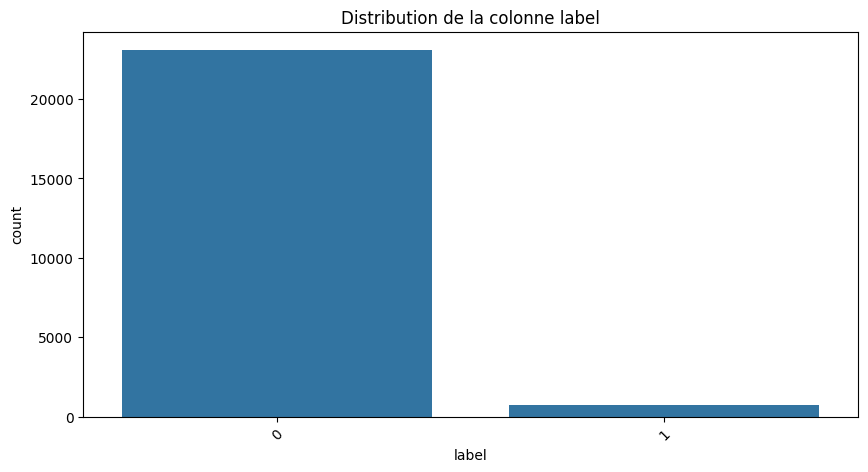

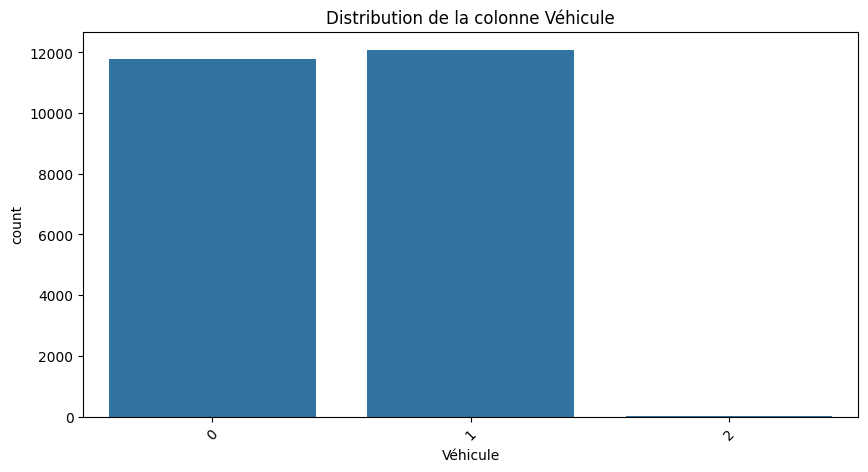

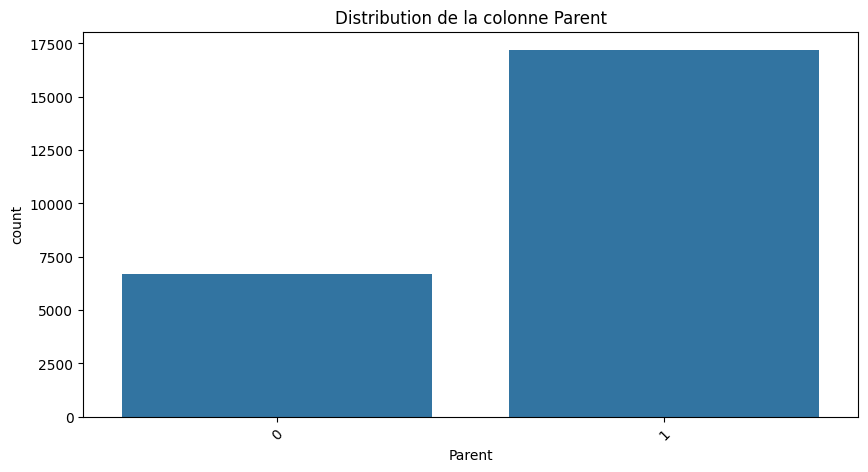

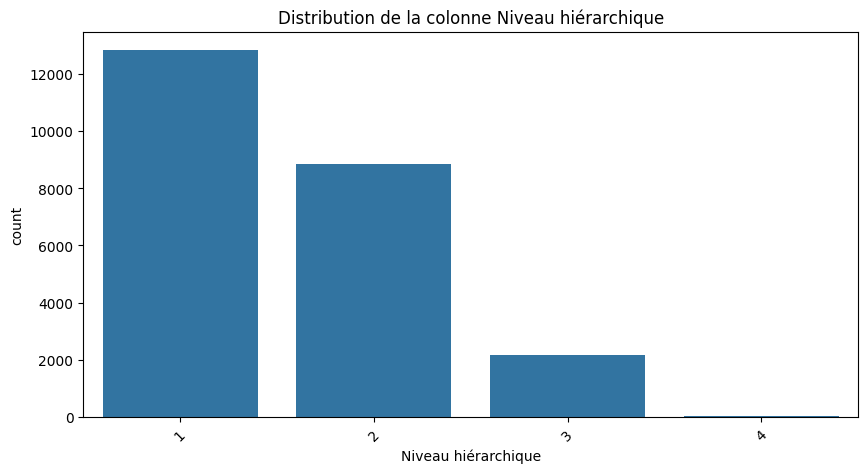

In [126]:
#plot des colones discrètes
for col in discrete_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col}")
    plt.xticks(rotation=45)
    plt.show()

L'analyse de la distribution de ces colonnes nous indique que :

* La colonne **Niveau hiérarchique** suit une structure pyramidale très marquée : une grande majorité se trouve au niveau **1** (plus de 12 000), le volume diminue d'un tier pour le niveau **2**, devient faible pour le niveau **3** et est quasi inexistant pour le niveau **4**.
* La colonne **Etablissement** montre une répartition très inégale. Alors que la plupart des établissements ont un effectif faible et stable (entre 200 et 800), l'établissement **28** se détache de manière spectaculaire avec plus de 8 000 individus, suivi de loin par le **27**. C'est clairement le site majeur de l'organisation.
* La colonne **Parent** est binaire, avec une nette majorité d'individus identifiés par le label **1** (plus de 17 000) contre environ 6 500 pour le label **0**.
* La colonne **Véhicule** est presque équitablement répartie entre les catégories **0** et **1** (autour de 12 000 chacune), tandis que la catégorie **2** est marginale.
* La colonne **label** (qui semble être notre variable cible) présente un **fort déséquilibre de classe** : la quasi-totalité des données appartient à la classe **0** (plus de 20 000), alors que la classe **1** est très minoritaire (moins de 1 000). Cela suggère un événement rare à prédire.


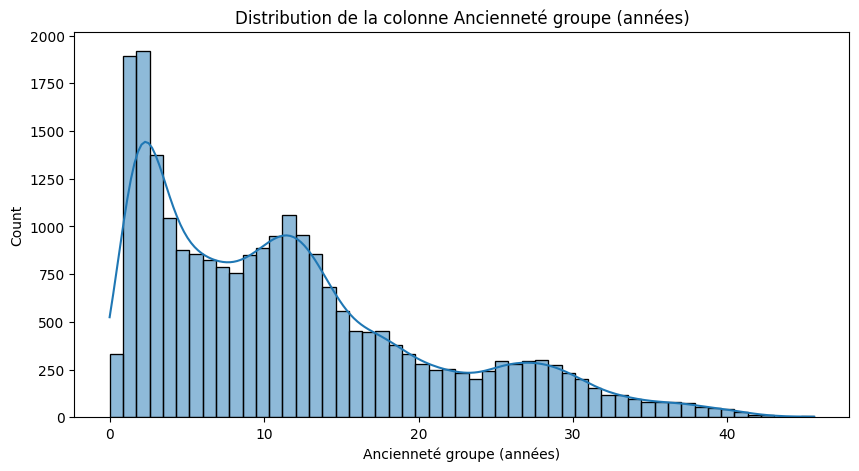

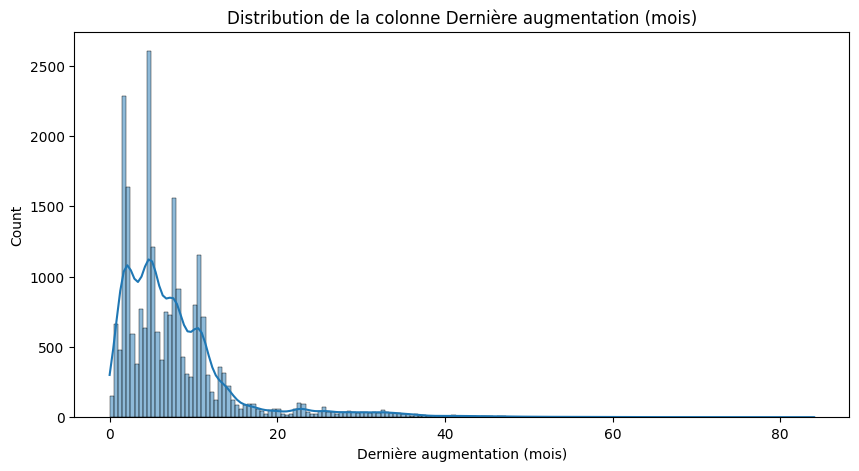

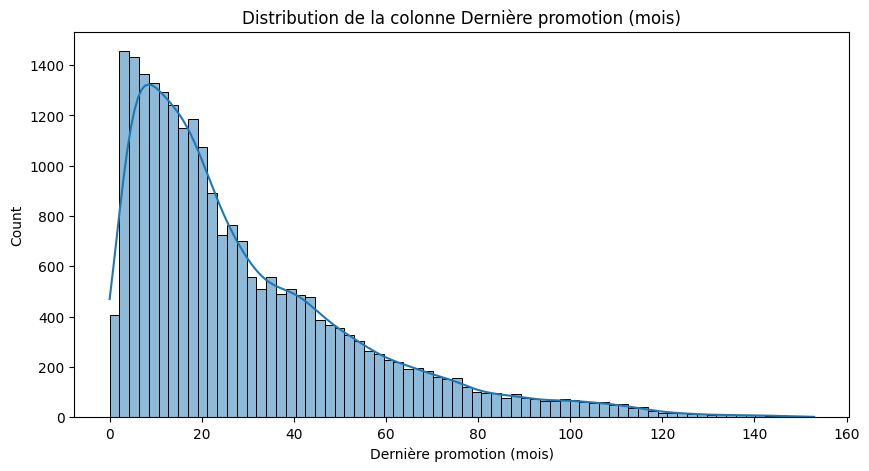

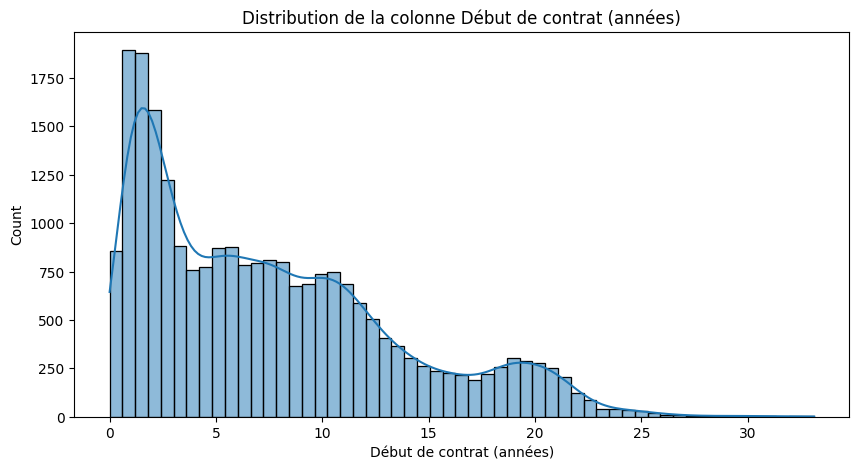

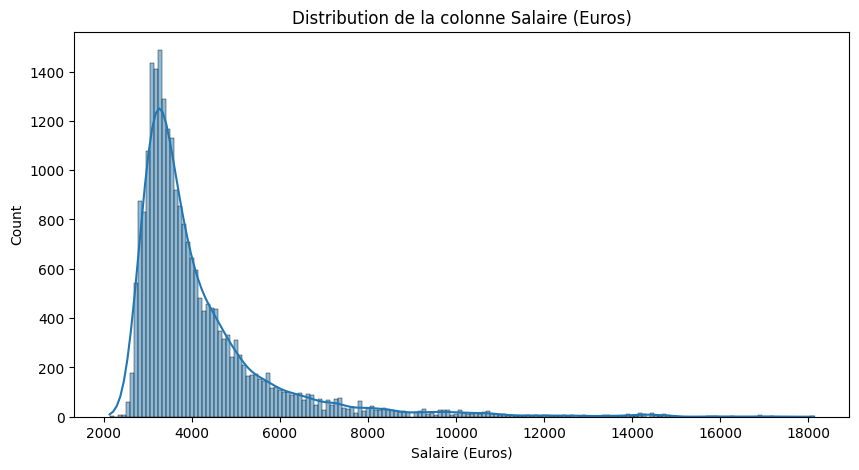

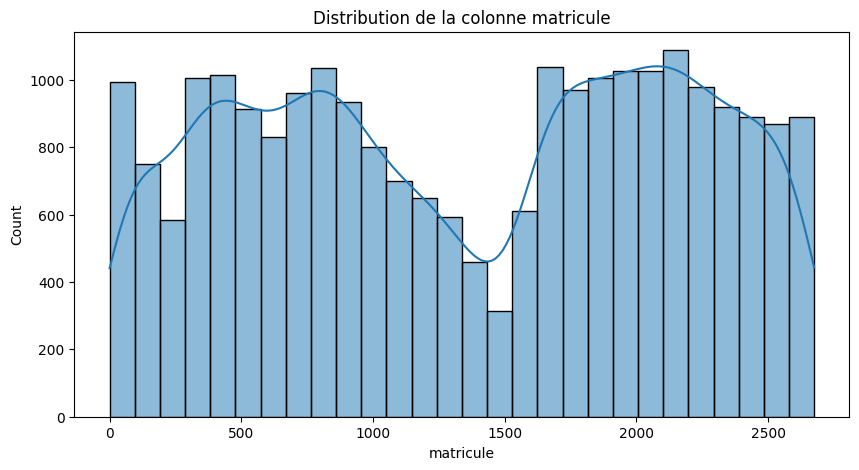

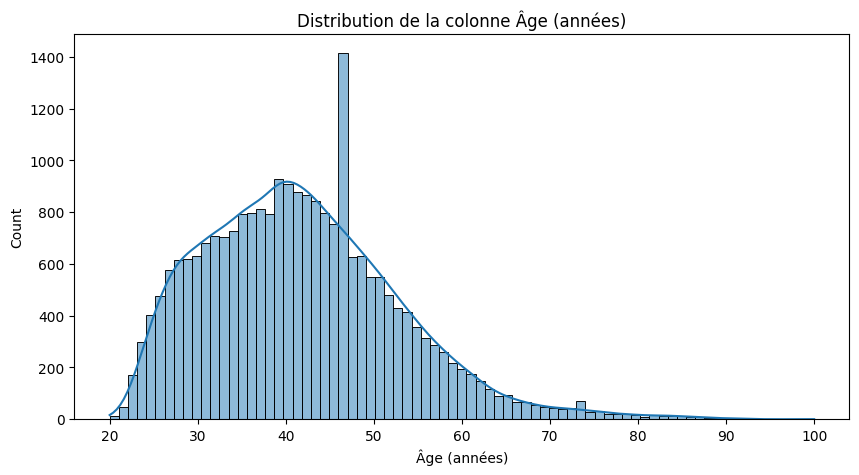

In [127]:
#plot des colones continues
for col in continus_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col], kde=True)
    plt.title(f"Distribution de la colonne {col}")
    plt.show()

L'analyse de la distribution des colones continues nous indique que:
- La colone **Ancienneté du groupe** a une distribution un peu asymétrique avec une majorité ayant une ancienneté de 0 à 15 ans et une minorité ayant une ancienneté de 15 à 30 ans. Il y a aussi quelques outliers avec une ancienneté de plus de 30 ans.
- La colone **dernière augmentation** a une distribution très asymétrique avec une majorité ayant une dernière augmentation de 0 à 15 mois et une minorité ayant une dernière augmentation plus loin.
- La colone **dernière promotion** a une distribution très asymétrique avec une majorité ayant une dernière promotion de 0 à 20 mois et une minorité ayant une dernière promotion plus loin.
- La colone **début de contrat** a une distribution assez constanteentre 5 et 10 ans, un pic entre 0 et 5 ans et une minorité ayant un début de contrat de plus de 10 ans.
- La colone **Salaire** a une distribution très asymétrique avec une majorité ayant un salaire de 0 à 50k et une minorité ayant un salaire plus élevé.
- La colone **matricule** est plus ou moins constante d'ailleurs je vois mal l'utilité de cette colone.
- La colone **d'âge** est une belle gaussienne avec une moyenne d'environ 40 mais avec un pics au alentour de 46 ans ce qui est étranges (on va investiguer)



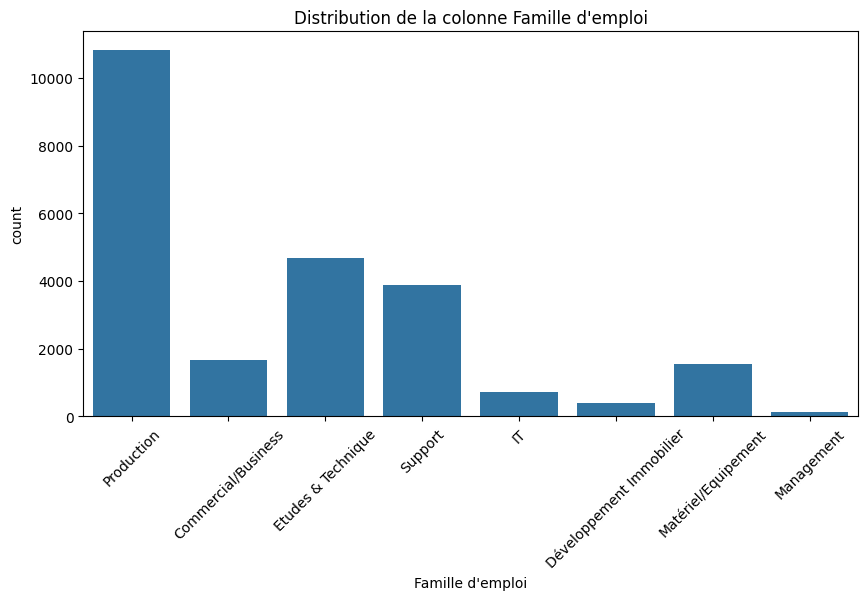

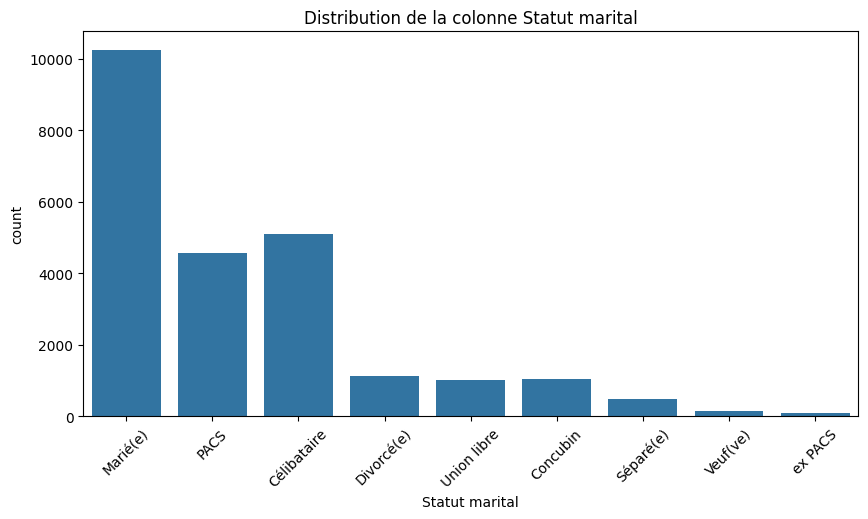

In [128]:
#plot colones str
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col}")
    plt.xticks(rotation=45)
    plt.show()

- La colonne **Statut marital** présente une forte concentration sur le profil Marié(e) (plus de 10 000 individus), suivi par les Célibataires et les PACS qui tournent autour de 4 500 à 5 000. Les autres catégories (Divorcé, Union libre, etc.) sont très minoritaires, avec moins de 1 000 individus chacune.

- La colonne **Famille d'emploi** est dominée de façon écrasante par la catégorie Production (plus de 10 000 individus), ce qui suggère un profil d'entreprise très opérationnel ou industriel.

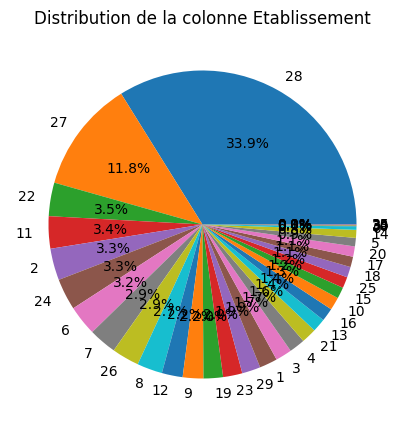

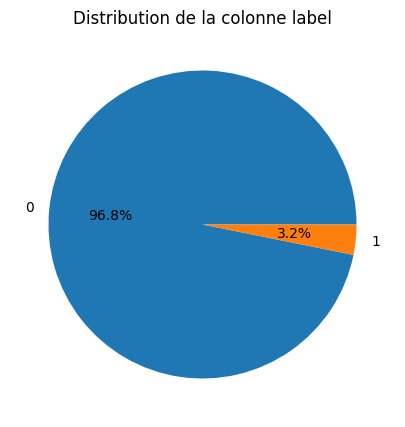

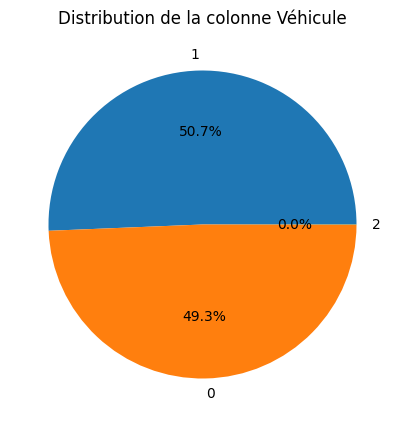

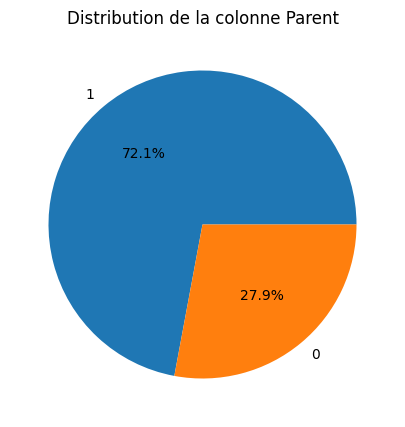

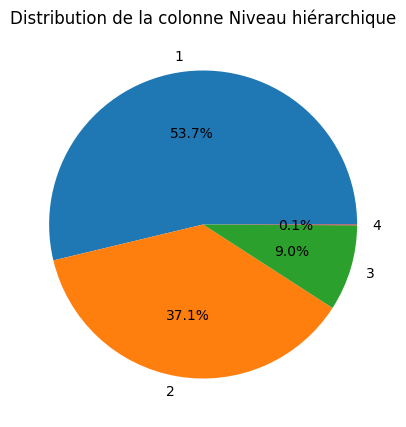

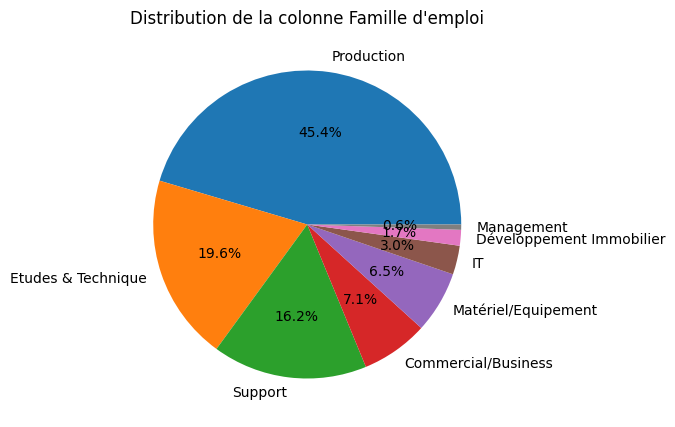

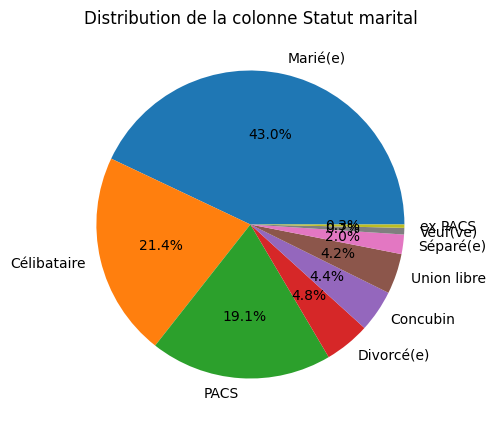

In [129]:
#plot pie chart pour les colones discrètes et str
for col in discrete_columns+str_columns:
    plt.figure(figsize=(10,5))
    df_rh[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"Distribution de la colonne {col}")
    plt.ylabel('')
    plt.show()

essayons deux méthodes:
- label encoding
- one hot encoding

In [130]:
#Label encoding pour les colones str
dict_label_encoding = {}
for col in str_columns:
    df_rh[col] = df_rh[col].astype('category')
    dict_label_encoding[col] = dict(enumerate(df_rh[col].cat.categories))
    df_rh[col] = df_rh[col].cat.codes
dict_label_encoding

{"Famille d'emploi": {0: 'Commercial/Business',
  1: 'Développement Immobilier',
  2: 'Etudes & Technique',
  3: 'IT',
  4: 'Management',
  5: 'Matériel/Equipement',
  6: 'Production',
  7: 'Support'},
 'Statut marital': {0: 'Concubin',
  1: 'Célibataire',
  2: 'Divorcé(e)',
  3: 'Marié(e)',
  4: 'PACS',
  5: 'Séparé(e)',
  6: 'Union libre',
  7: 'Veuf(ve)',
  8: 'ex PACS'}}

In [131]:
df_rh[str_columns].nunique()

Famille d'emploi    8
Statut marital      9
dtype: int64

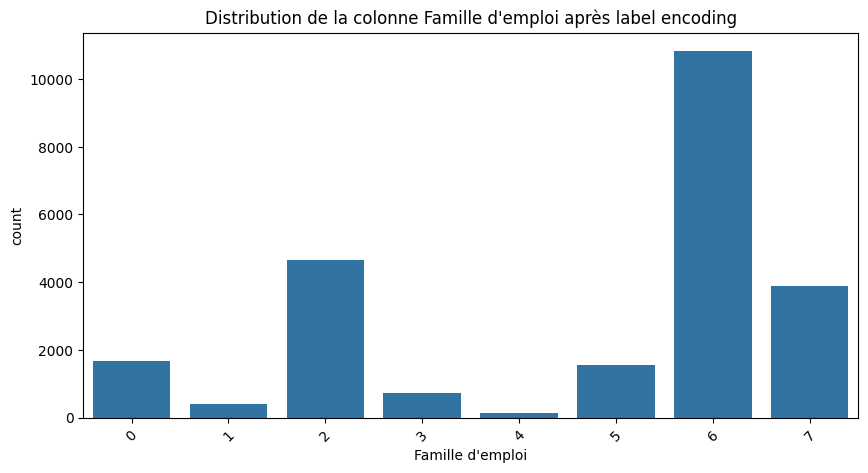

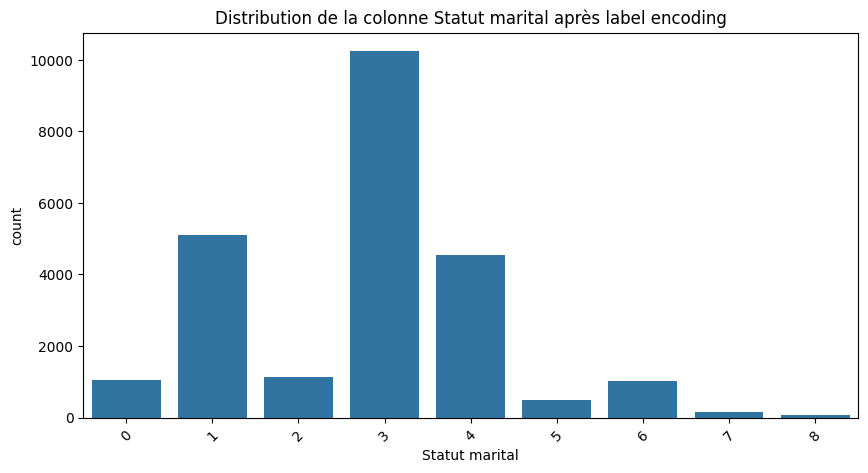

In [132]:
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col)
    plt.title(f"Distribution de la colonne {col} après label encoding")
    plt.xticks(rotation=45)
    plt.show()

## Parcours d'une personne qui a démissionné et une personne qui n'a pas démissionné

Exhibons le chemin d'une personne qui a démissionné et une personne qui n'a pas démissionné pour voir les différences entre les deux.

## Correlation entre les différentes colones

Premièrement, on va faire la correlation entre les différentes colones pour voir si il y a des colones qui sont fortement corrélées entre elles. Si c'est le cas, on pourra peut-être supprimer une de ces colones pour éviter la multicolinéarité.

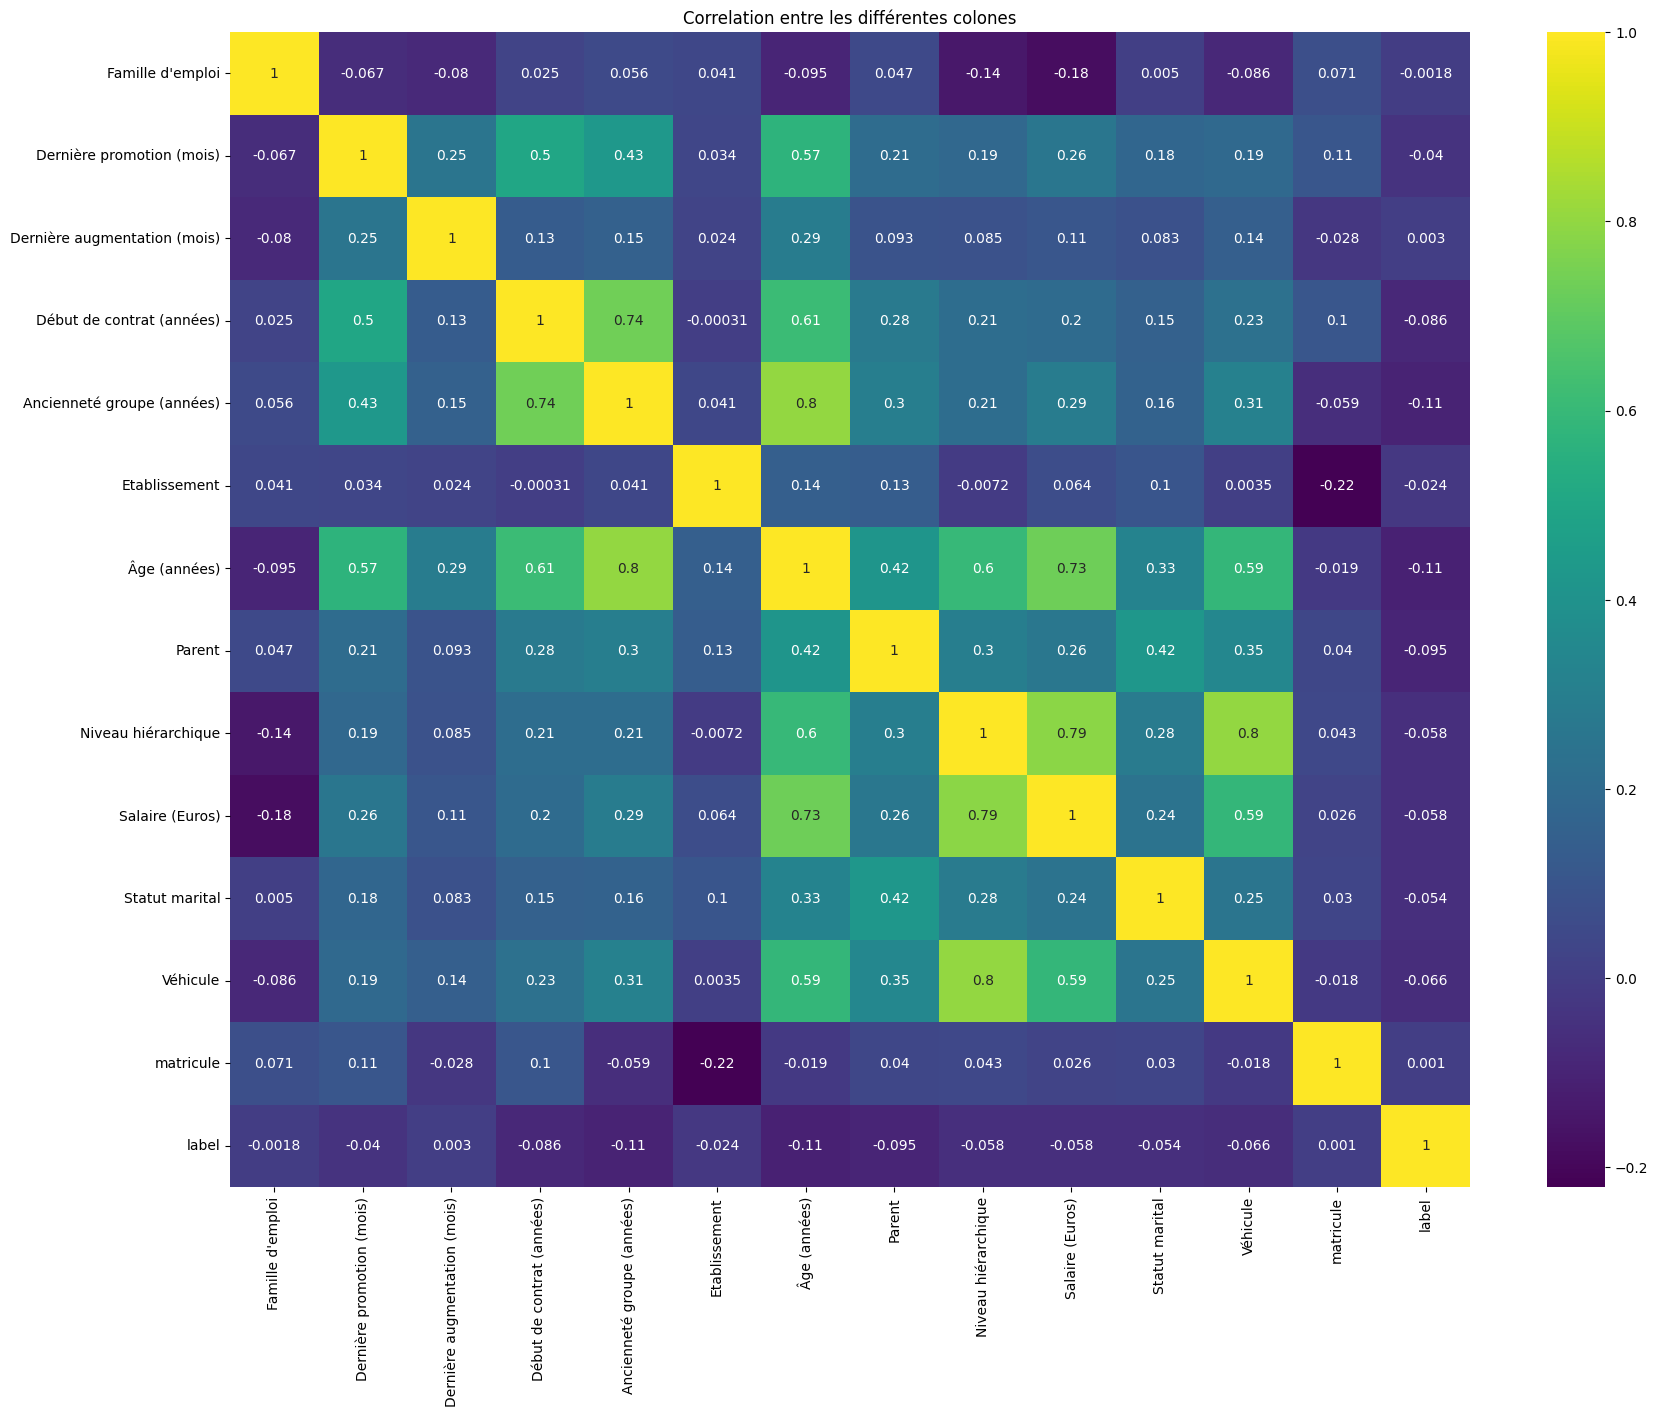

In [133]:
plt.figure(figsize=(20,15))
sns.heatmap(df_rh.corr(), annot=True, cmap='viridis')
plt.title("Correlation entre les différentes colones")
plt.show()

<Axes: >

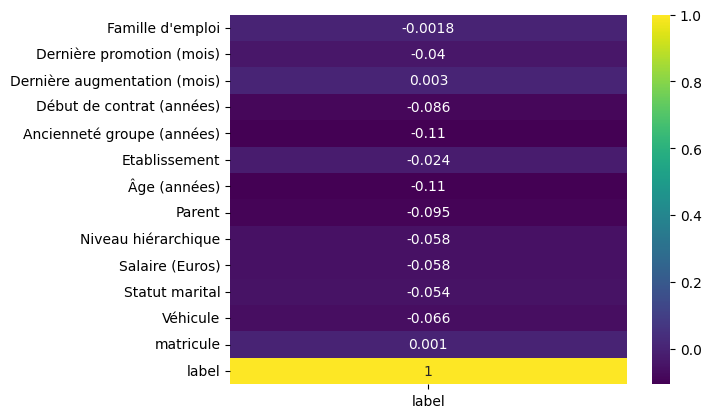

In [134]:
sns.heatmap(df_rh.corr()[['label']], annot=True, cmap='viridis')

### 1. La relation avec la cible ("label")

D'après la deuxième image (le zoom sur la colonne `label`), on observe quelque chose de frappant : **aucune variable n'est fortement corrélée avec le label.**

* Les corrélations oscillent entre **-0,11** (Ancienneté groupe et Âge) et **0,071** (Famille d'emploi).
* **Interprétation :** Cela signifie qu'aucune variable prise isolément ne peut prédire linéairement le `label`.
---
### 2. Les fortes corrélations (Multicolinéarité)

* **Le bloc de carrière :**
* **Âge & Ancienneté groupe (0,80) :** Très forte corrélation logique (plus on est âgé, plus on a tendance à avoir de l'ancienneté).
* **Début de contrat & Ancienneté (0,74) :** Ces deux variables mesurent quasiment la même chose.


* **Le bloc de statut hiérarchique :**
* **Niveau hiérarchique & Salaire (0,79) :** Sans surprise, plus le niveau est élevé, plus le salaire l'est.
* **Niveau hiérarchique & Véhicule (0,80) :** Indique souvent que le véhicule de fonction est un avantage lié au rang.
* **Âge & Salaire (0,73) :** Le salaire progresse avec l'expérience et l'âge.

---

### 3. Les variables "neutres"

* **Matricule :** Sa corrélation avec les autres variables est proche de zéro (sauf un léger lien négatif avec l'Établissement). C'est normal, un identifiant ne devrait pas avoir de valeur prédictive. 
* **Famille d'emploi :** Très peu corrélée au reste, ce qui suggère que c'est une variable catégorielle indépendante qui apporte une information unique, même si elle est faible ici.

---

### Conclusions 

1. **Faible signal :** Le "label" semble difficile à prédire avec ces variables telles quelles.
2. **Nettoyage :** On a beaucoup de redondance (Âge, Ancienneté, Salaire, Niveau hiérarchique). Pour simplifier le modèle, on pourrait ne garder que les plus significatives.
3. **Feature Engineering :** Puisque les corrélations linéaires sont faibles avec le label, on peut créer de nouvelles variables (ex: ratio salaire/ancienneté) ou vérifier s'il n'y a pas des relations non-linéaires.


## Analyse supplémentaire

<Figure size 2000x1500 with 0 Axes>

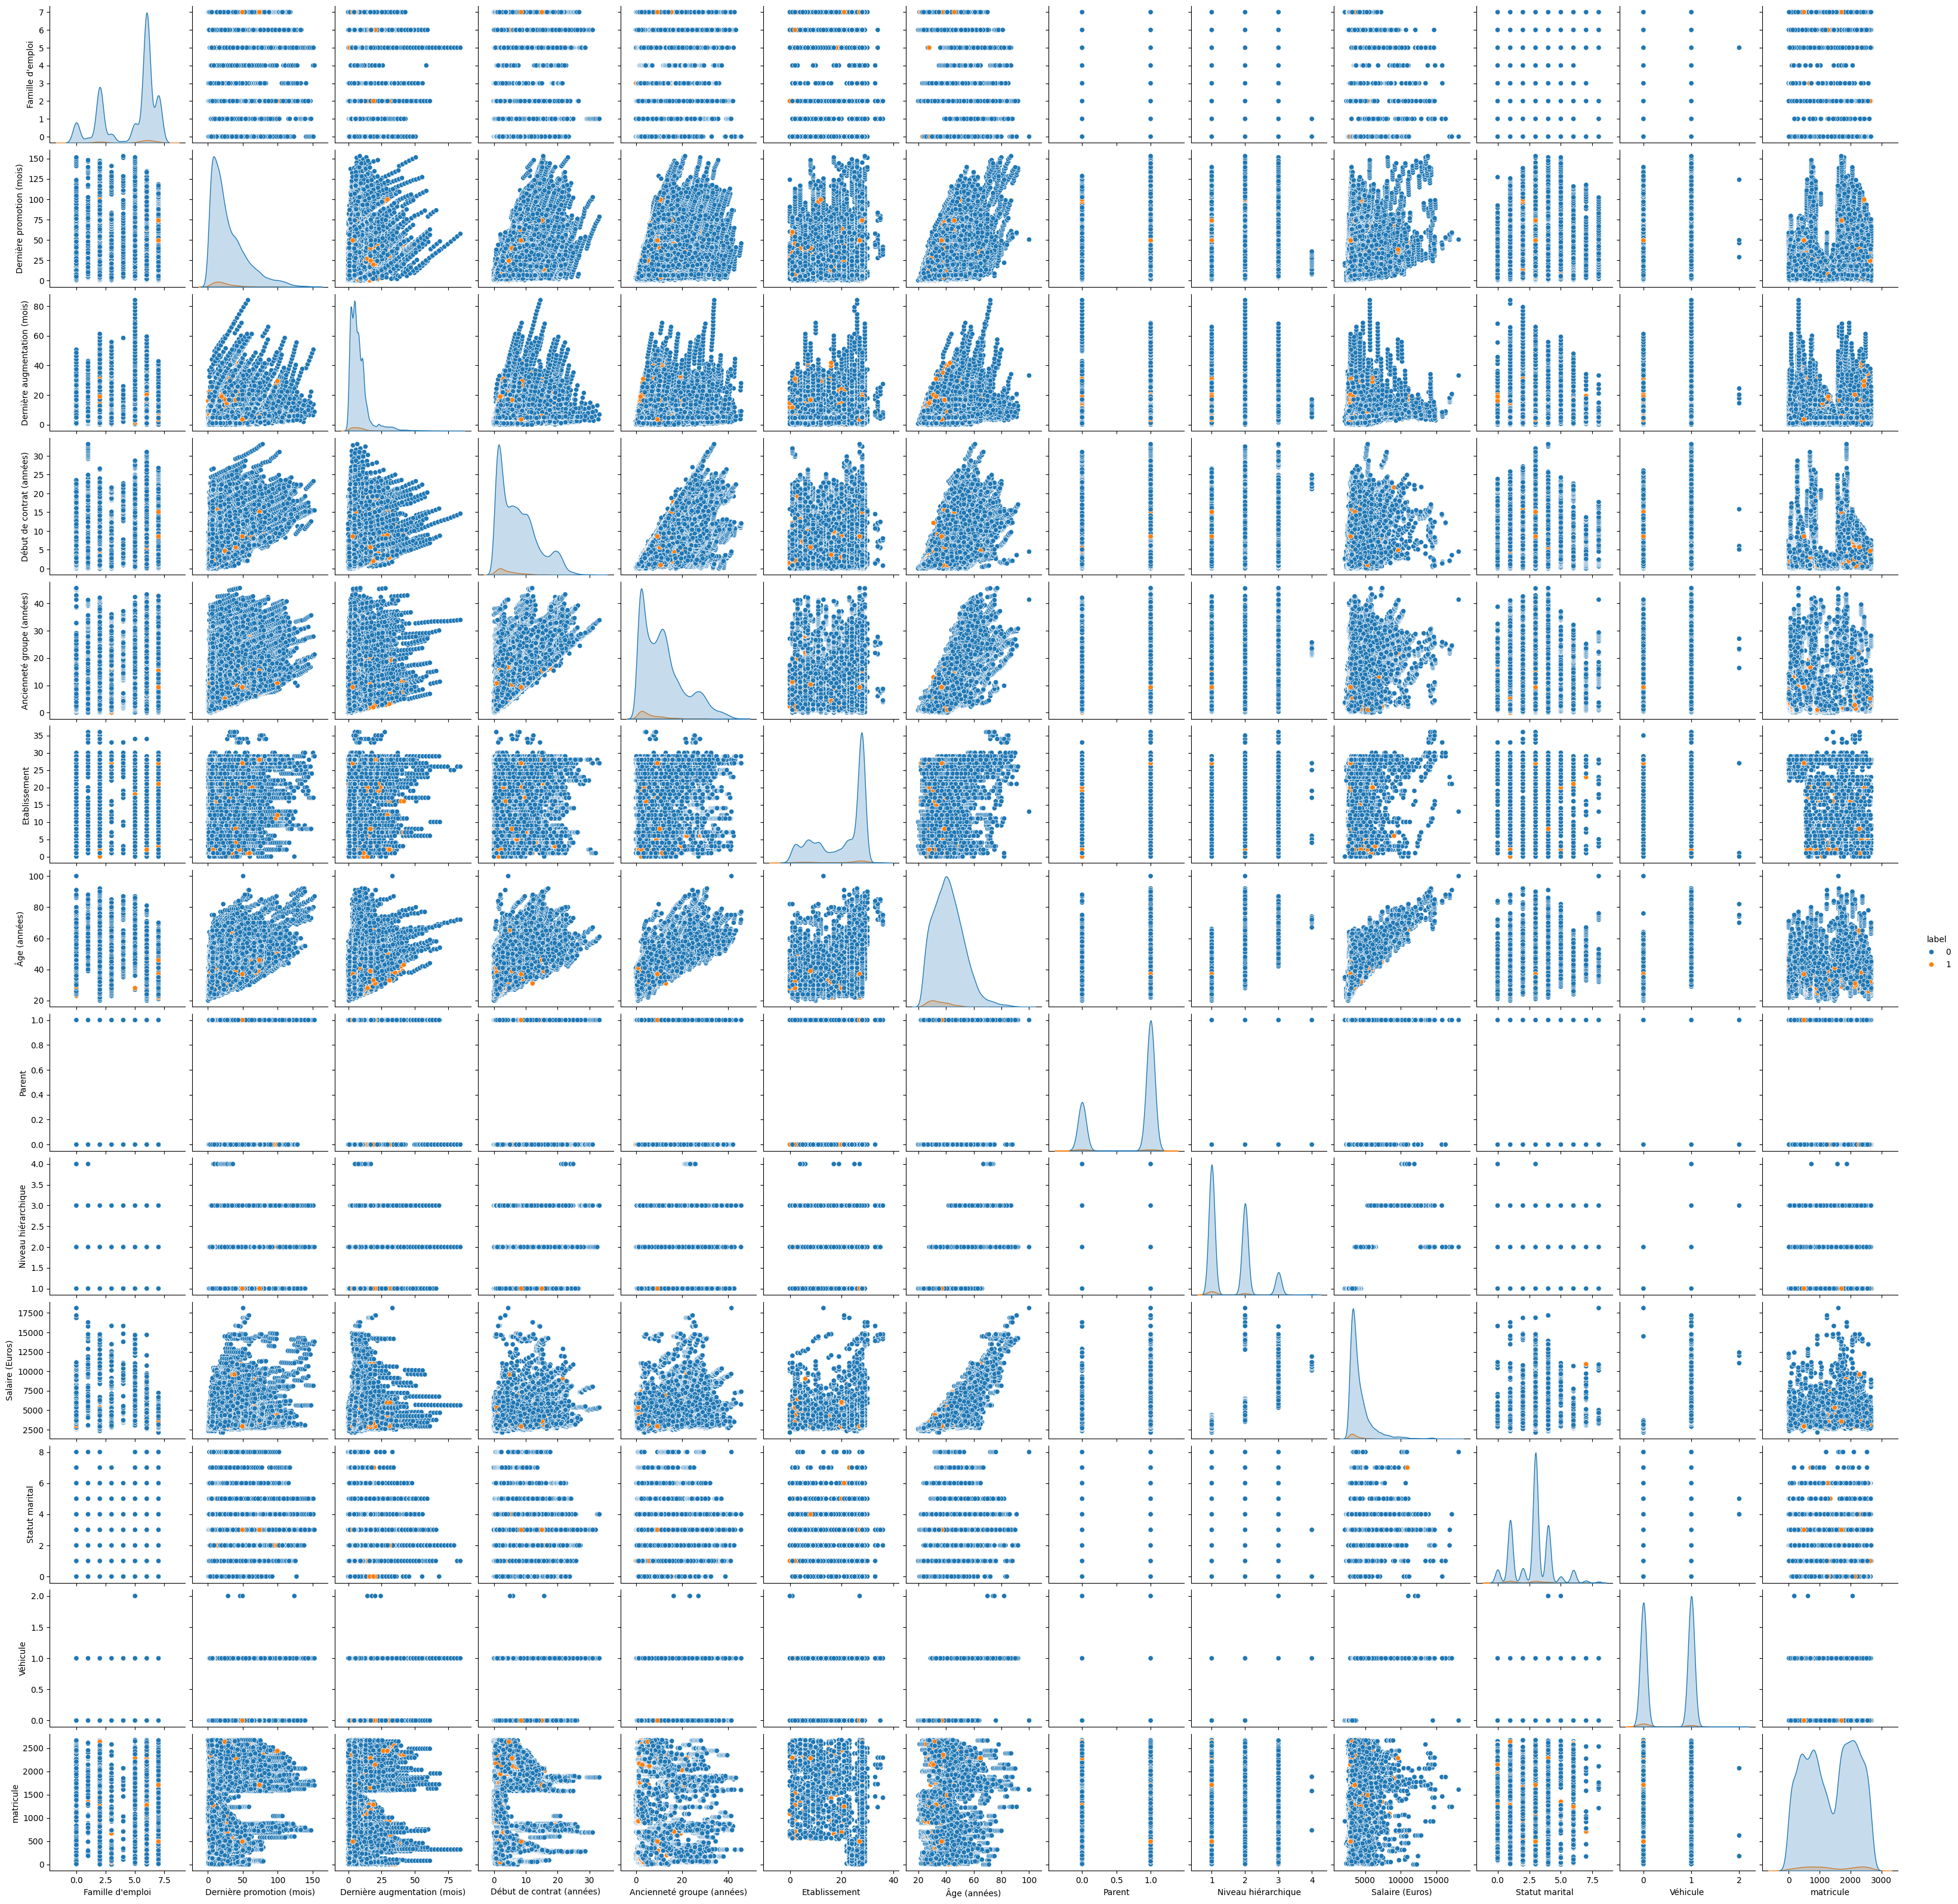

In [135]:
plt.figure(figsize=(20,15))
sns.pairplot(df_rh, hue='label', diag_kind='kde')
plt.show()

**1. Un fort déséquilibre des classes (Class Imbalance)**
La première chose qui me saute aux yeux, c'est l'omniprésence des points bleus (`label = 0`) par rapport aux points oranges (`label = 1`). C'est particulièrement visible sur les courbes de densité (sur la diagonale) : les courbes oranges sont presque plates en comparaison.

* **Mon action possible pour la suite :** Mon jeu de données est clairement déséquilibré. Si j'entraîne mon modèle directement, il risque de prédire systématiquement "0" pour avoir un bon score global. Je vais devoir appliquer des techniques de rééquilibrage, comme le sur-échantillonnage (SMOTE) ou ajuster les poids des classes dans mon algorithme.

**2. L'absence de séparation linéaire évidente**
En regardant les nuages de points (scatter plots), je cherchais à voir si certaines combinaisons de variables permettaient d'isoler la classe 1. Malheureusement, les points oranges sont complètement "noyés" au milieu des points bleus. Il n'y a pas de clusters distincts.

* **Mon action pour la suite :** Cela confirme ce que j'avais observé dans ma matrice de corrélation. Une simple régression logistique ne fonctionnera pas bien ici. Je devrai m'orienter vers des modèles capables de capter des règles non linéaires et des interactions complexes, comme les Random Forests (Forêts Aléatoires) ou XGBoost.

**3. Des distributions très asymétriques (Skewness)**
Les graphiques sur la diagonale m'indiquent que plusieurs de mes variables numériques ne suivent pas une loi normale. Par exemple, le `Salaire`, la `Dernière promotion` ou le `Début de contrat` sont très étirés vers la droite (asymétrie positive). La majorité des employés se concentrent sur des valeurs basses, avec une longue traîne vers des valeurs extrêmes.

* **Mon action possible pour la suite :** Selon le modèle que je vais choisir au final, je note qu'il sera peut-être nécessaire d'appliquer une transformation (comme le passage au logarithme) sur ces variables pour recentrer leurs distributions.

**4. Confirmation visuelle de la multicolinéarité**
Je retrouve visuellement les fortes corrélations que j'avais identifiées précédemment. Par exemple, le graphique croisant l'`Âge` et l'`Ancienneté groupe`, ou encore le `Niveau hiérarchique` et le `Salaire`, montre des alignements de points très nets, formant presque des lignes droites.

il faudra voir s'il est utile de supprimer une de ces colones


# 2. Analyse des variables sensibles et biais potentiels

# 3. Apprentissage automatique

pour traiter les valeur numérique continue on va les standardiser pour les mettre à la même échelle. Pour les colones catégorielles, on va utiliser du one hot encoding pour les transformer en variables numériques.

## preparation dataset

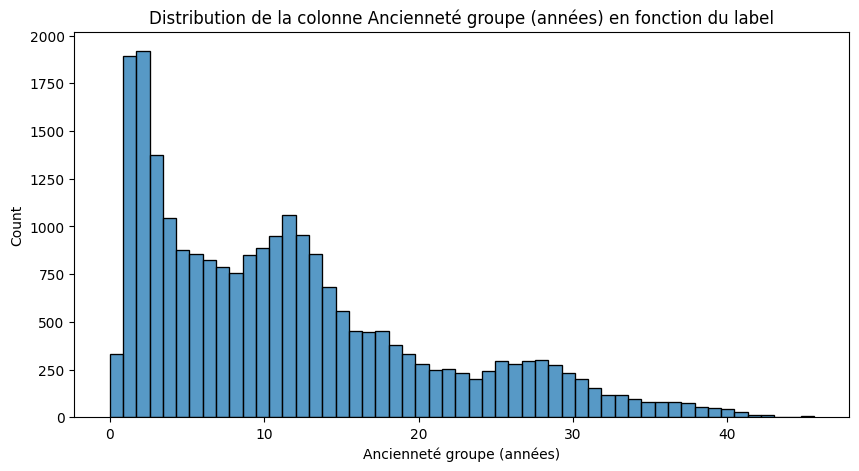

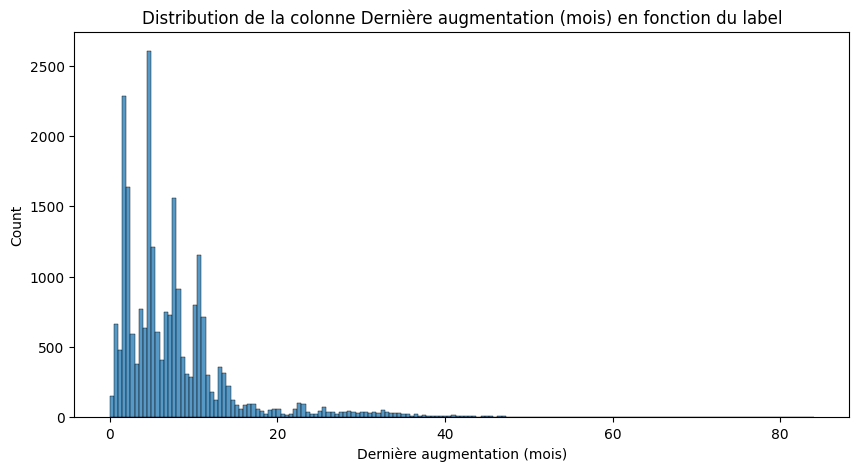

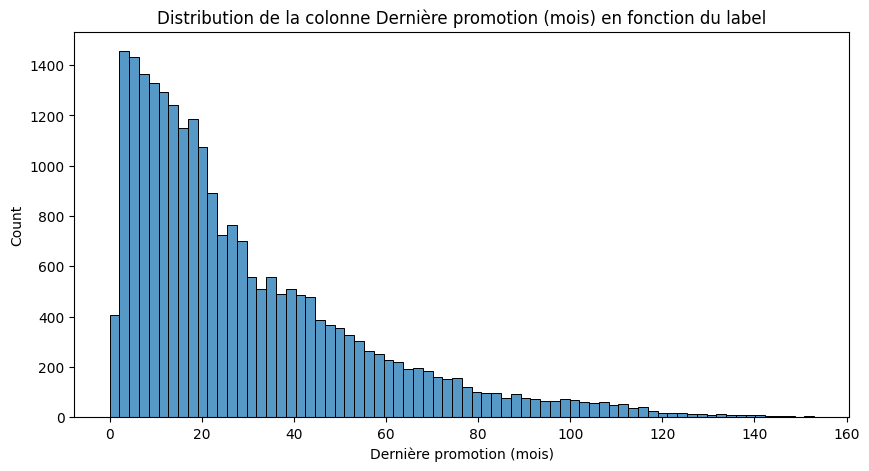

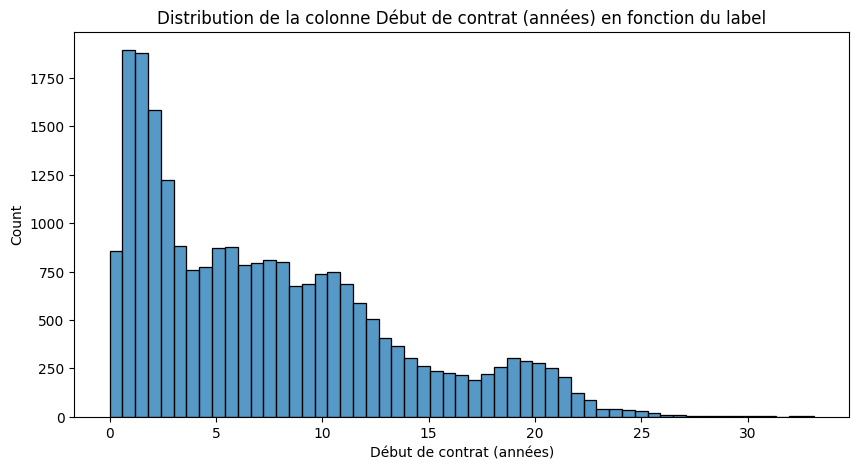

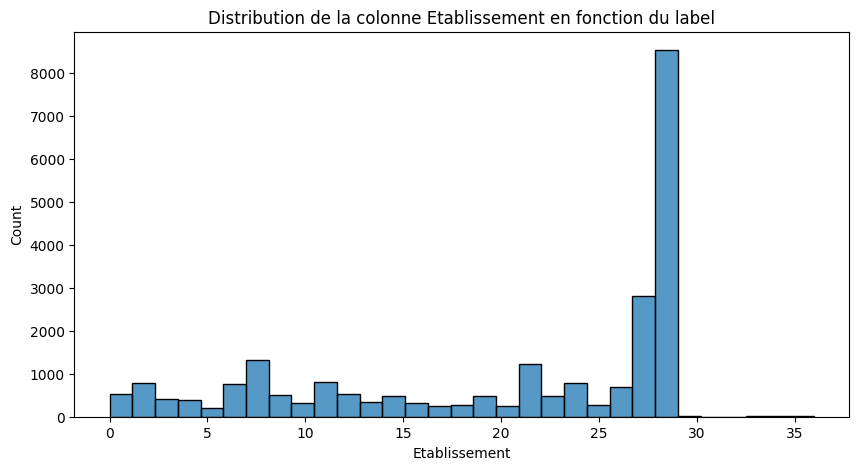

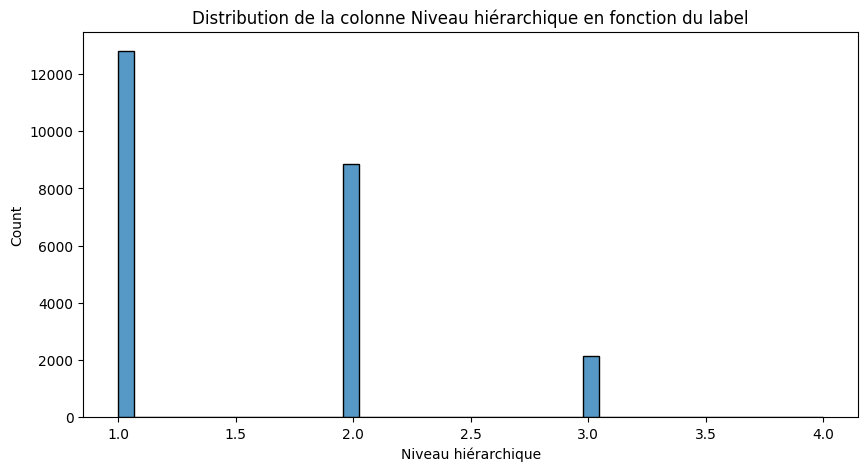

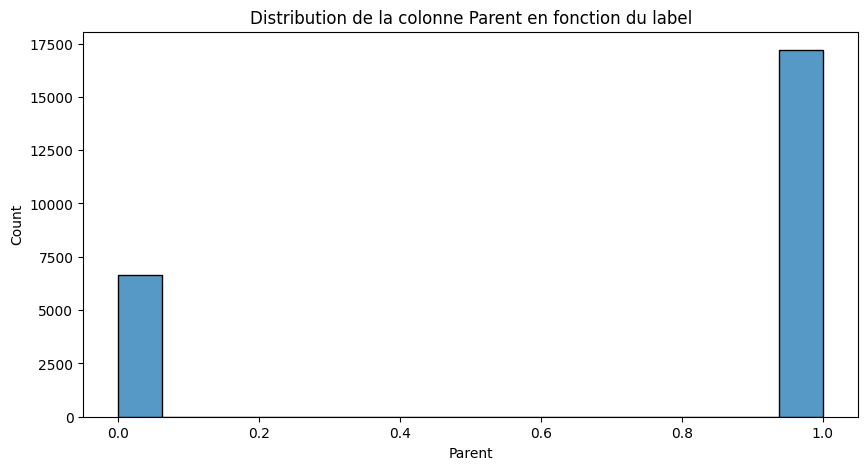

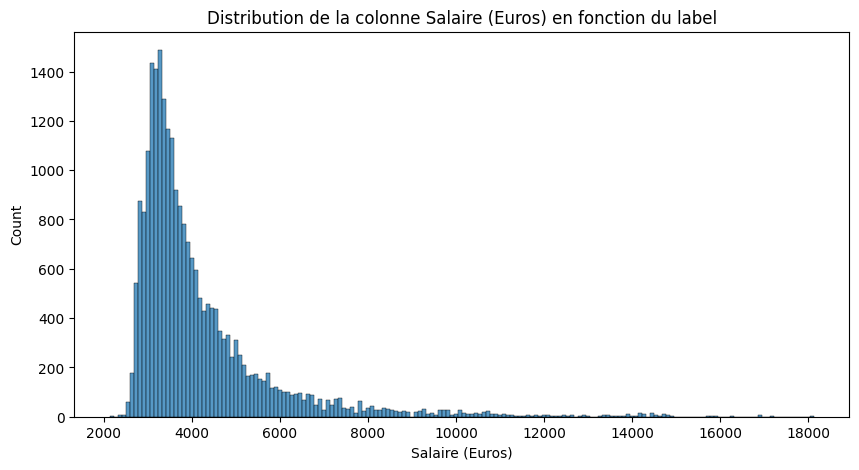

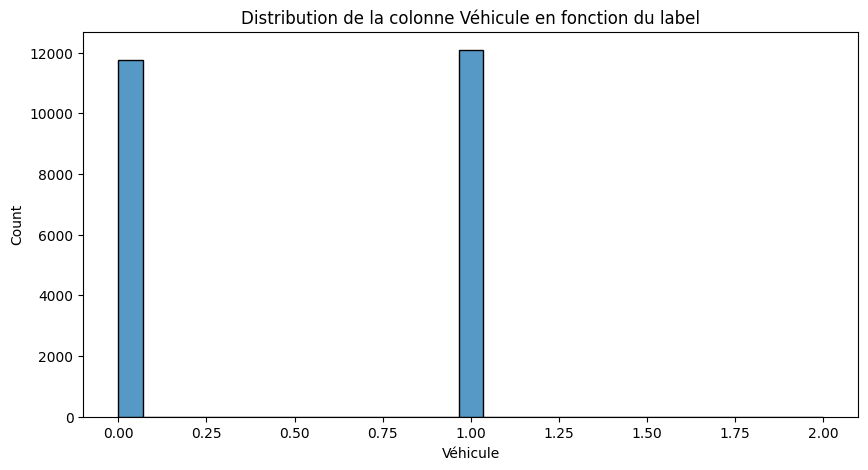

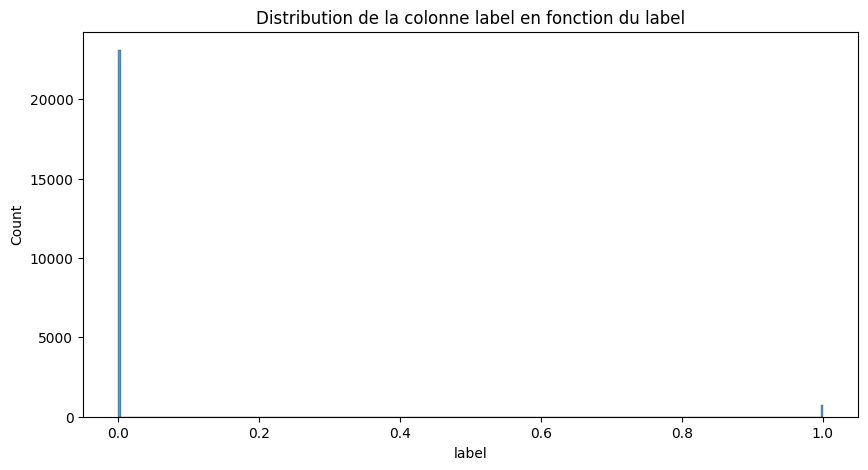

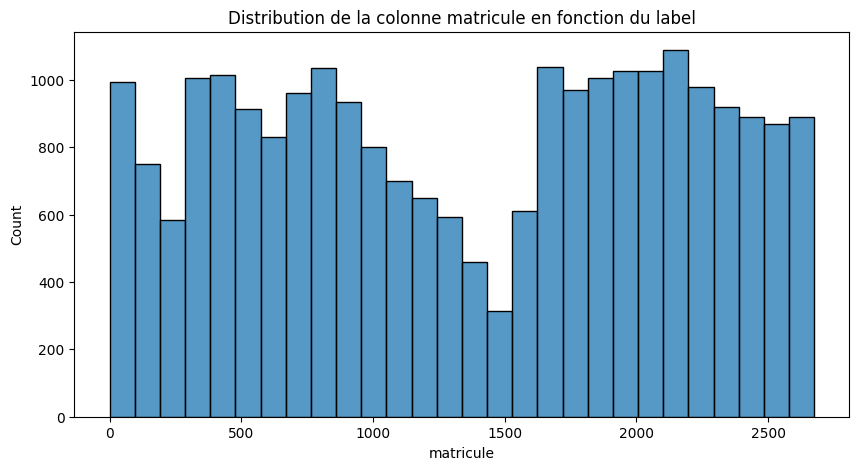

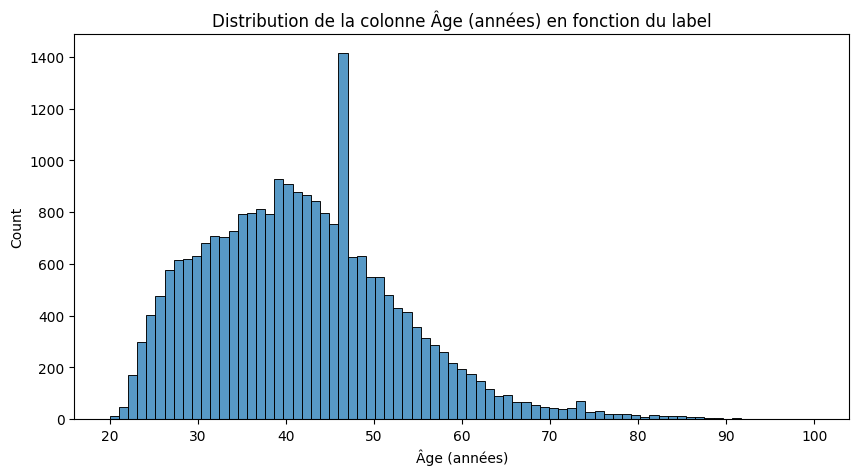

In [136]:
#plot distribution de la colone des colones
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_rh[col])
    plt.title(f"Distribution de la colonne {col} en fonction du label")
    plt.show()

In [137]:
print(continus_columns)

['Ancienneté groupe (années)', 'Dernière augmentation (mois)', 'Dernière promotion (mois)', 'Début de contrat (années)', 'Salaire (Euros)', 'matricule', 'Âge (années)']


In [138]:
print(discrete_columns)

['Etablissement', 'label', 'Véhicule', 'Parent', 'Niveau hiérarchique']


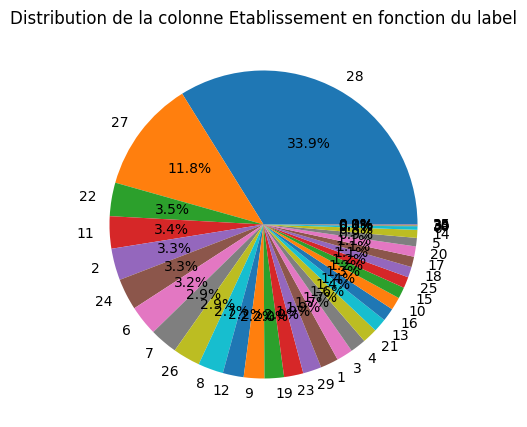

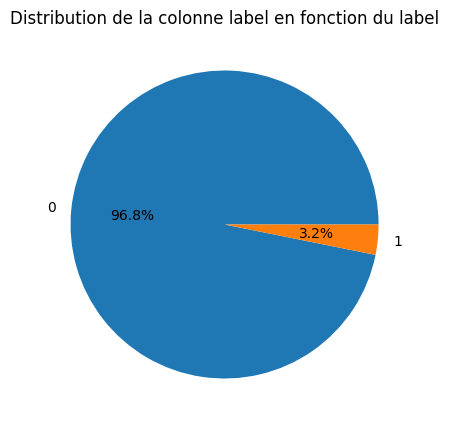

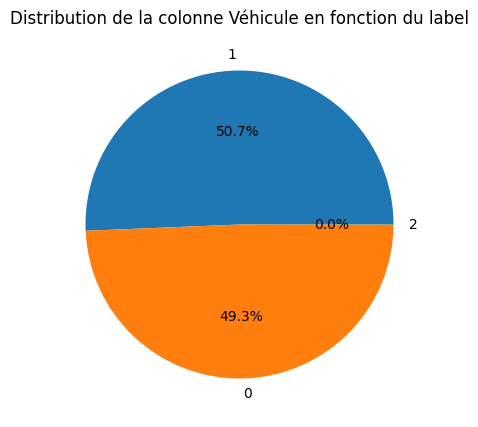

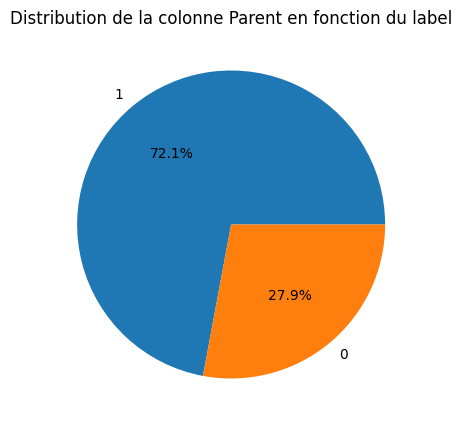

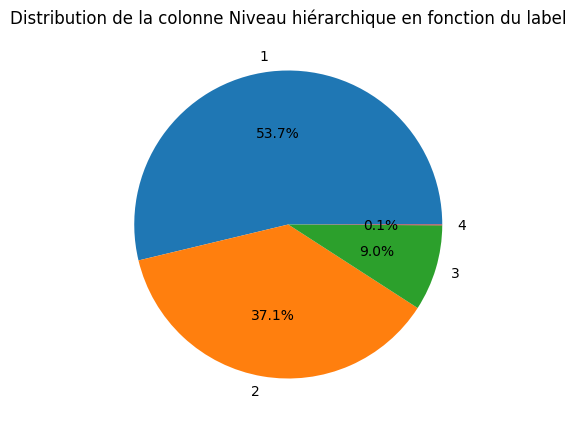

In [139]:
#pie discrete columns
for col in discrete_columns:
    plt.figure(figsize=(10,5))
    df_rh[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"Distribution de la colonne {col} en fonction du label")
    plt.ylabel('')
    plt.show()

Text(0.5, 1.0, 'Relation entre niveau hiérarchique et salaire')

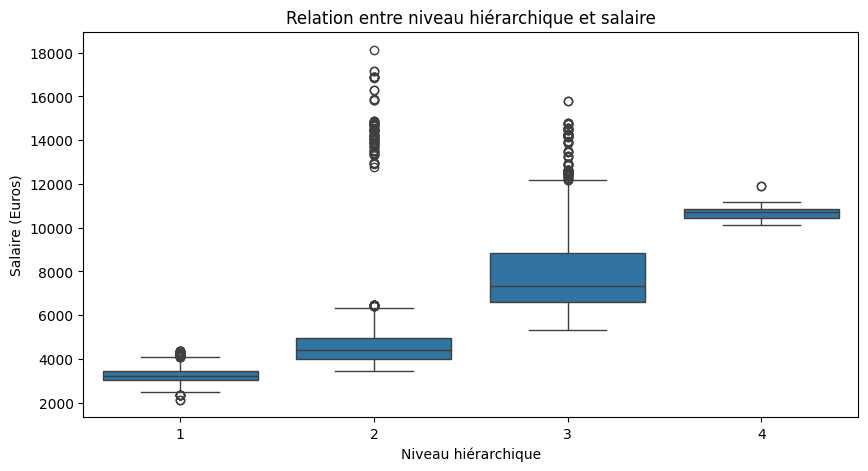

In [140]:
#montrer relation entre niveau hiérarchique et salaire
plt.figure(figsize=(10,5))
sns.boxplot(data=df_rh, x='Niveau hiérarchique', y='Salaire (Euros)')
plt.title("Relation entre niveau hiérarchique et salaire")  

On voit que l'on a un lien entre le niveau hiérarchique est le salaire donc plus le niveau hiérarchique est élevé, plus la personne a un poste important donc il ya un sens à garder sous forme ordinale et pas de one hot encoding pour cette colone.

la question est pour la colone établissement qui n'as pas vraiment de lien mais comme il ya 28 établissements donc on va faire plusieurs tests.

In [141]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
#cross validation
from sklearn.model_selection import cross_validate

pipeline_preprocessing = make_pipeline(
    StandardScaler(),)
X = df_rh.drop(columns=['label'])
y = df_rh['label']

In [142]:

scoring = ['accuracy','balanced_accuracy', 'f1','f1_weighted', 'precision', 'recall']

In [143]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      
    stratify=y,         # garder la répartition car on est très déséquilibré
    random_state=42     
)

## XGBoost

In [144]:
#imbalance level
y.value_counts(normalize=True)

label
0    0.968353
1    0.031647
Name: proportion, dtype: float64

In [145]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)

pipeline_xgb = make_pipeline(pipeline_preprocessing, xgb_clf)
scores = cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)
scores_df = pd.DataFrame(scores)
scores_df

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.124049,0.018996,0.956510,0.667130,0.341270,0.957510,0.325758,0.358333
1,0.134513,0.017006,0.953105,0.656029,0.314176,0.954751,0.292857,0.338843
2,0.097510,0.015507,0.948127,0.633474,0.266667,0.950718,0.241611,0.297521
3,0.097515,0.018005,0.954676,0.652843,0.316206,0.955628,0.303030,0.330579
4,0.145051,0.025568,0.951009,0.630965,0.272374,0.952389,0.257353,0.289256


On voit que le dataset est tellement déséquilibré que le modèle va forcément être biaisé vers la classe majoritaire (label = 0) même avec le changements des poids des classe 
s (j'ai essayé avec du SMOTE mais c'était encore pire).

Trouvons les meilleurs poids

In [146]:
from sklearn.model_selection import GridSearchCV


param_grid_xgb = {
    'xgbclassifier__scale_pos_weight': [1, 5, 10, 20, 30, 50],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3],
    'xgbclassifier__n_estimators': [100, 200, 300],
}

grid_xgb = GridSearchCV(
    pipeline_xgb, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train)
print("Best parameters:", grid_xgb.best_params_)
print("Best F1 score:", grid_xgb.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.3186689033430602


In [147]:
scores=cross_validate(pipeline_xgb, X_train, y_train, cv=cv, scoring=scoring)
scores_df = pd.DataFrame(scores)
print("=== XGBoost ===")
scores_df

=== XGBoost ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.135525,0.027000,0.956510,0.667130,0.341270,0.957510,0.325758,0.358333
1,0.180048,0.013999,0.953105,0.656029,0.314176,0.954751,0.292857,0.338843
2,0.136626,0.013000,0.948127,0.633474,0.266667,0.950718,0.241611,0.297521
3,0.117023,0.016999,0.954676,0.652843,0.316206,0.955628,0.303030,0.330579
4,0.111516,0.015001,0.951009,0.630965,0.272374,0.952389,0.257353,0.289256


Pour avoir un modèle final qui soit analysable je vais entraninner sur toutes les données pour faire une analyse de l'importance des features et voir les features les plus importantes pour la prédiction du label.

In [148]:
grid_xgb.best_estimator_.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipeline', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will rai

In [149]:
from sklearn.metrics import classification_report, confusion_matrix

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4621
           1       0.30      0.31      0.31       151

    accuracy                           0.96      4772
   macro avg       0.64      0.64      0.64      4772
weighted avg       0.96      0.96      0.96      4772



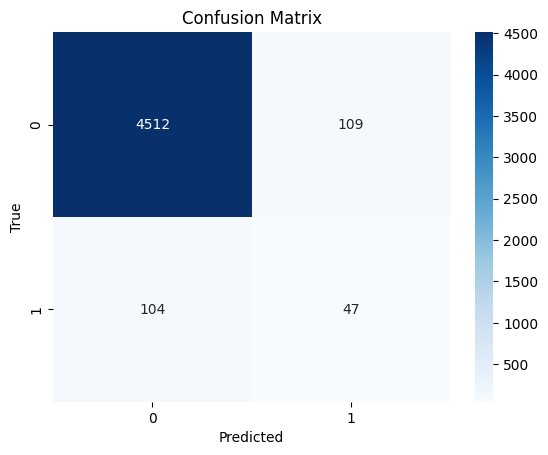

In [150]:
#show score 
y_pred = grid_xgb.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

On voit que l'on a quand même une amélioration du score en utilisant le f1 weighted au lieu du f1 classique, ce qui est logique vu que le dataset est déséquilibré. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

## Logistic Regression

In [151]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

pipeline_lr = make_pipeline(pipeline_preprocessing, lr_clf)
scores_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv, scoring=scoring)
scores_lr_df = pd.DataFrame(scores_lr)
print("=== Logistic Regression ===")
scores_lr_df

=== Logistic Regression ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.029020,0.011552,0.618811,0.658088,0.103512,0.737370,0.055888,0.700000
1,0.022000,0.012000,0.603615,0.667417,0.105263,0.725122,0.056688,0.735537
2,0.021985,0.011999,0.596804,0.667896,0.104712,0.719681,0.056320,0.743802
3,0.028521,0.017022,0.590254,0.652524,0.100115,0.714618,0.053803,0.719008
4,0.029984,0.018004,0.624312,0.642132,0.100376,0.741591,0.054311,0.661157


Même problème que pour XGBoost, le modèle est biaisé vers la classe majoritaire (label = 0). Je vais faire une gridsearch sur f1 weighted.

In [152]:
param_grid_lr = {
    'logisticregression__class_weight': [
        {0: 1, 1: w} for w in [1, 5, 10, 20, 30, 50]
    ],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['liblinear'],
}

grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train, y_train)
print("Best parameters:", grid_lr.best_params_)
print("Best F1 score:", grid_lr.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.12223552049808561


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [153]:
scores_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv, scoring=scoring)
scores_lr_df = pd.DataFrame(scores_lr)
print("=== Logistic Regression ===")
scores_lr_df

=== Logistic Regression ===


,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_f1_weighted,test_precision,test_recall
0,0.029324,0.012015,0.618811,0.658088,0.103512,0.737370,0.055888,0.700000
1,0.021983,0.012006,0.603615,0.667417,0.105263,0.725122,0.056688,0.735537
2,0.022512,0.011000,0.596804,0.667896,0.104712,0.719681,0.056320,0.743802
3,0.028433,0.011988,0.590254,0.652524,0.100115,0.714618,0.053803,0.719008
4,0.028002,0.018566,0.624312,0.642132,0.100376,0.741591,0.054311,0.661157


ON voit que le même score que pour XGBoost mais c'est normal au vu du déséquilibre du dataset et du fait que la régression logistique est un modèle linéaire qui ne peut pas capturer les interactions complexes entre les variables.

Maintenant entrainnons sur toutes les données pour faire une analyse de l'importance des features et voir les features les plus importantes pour la prédiction du label.

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4621
           1       0.30      0.31      0.31       151

    accuracy                           0.96      4772
   macro avg       0.64      0.64      0.64      4772
weighted avg       0.96      0.96      0.96      4772



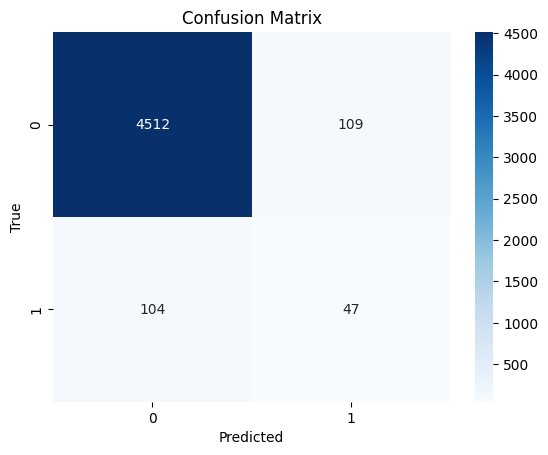

In [154]:
grid_xgb.best_estimator_.fit(X_train, y_train)
y_pred = grid_xgb.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## GAM

Dans un premier temps on va regarder la relation entre les différentes features et le label

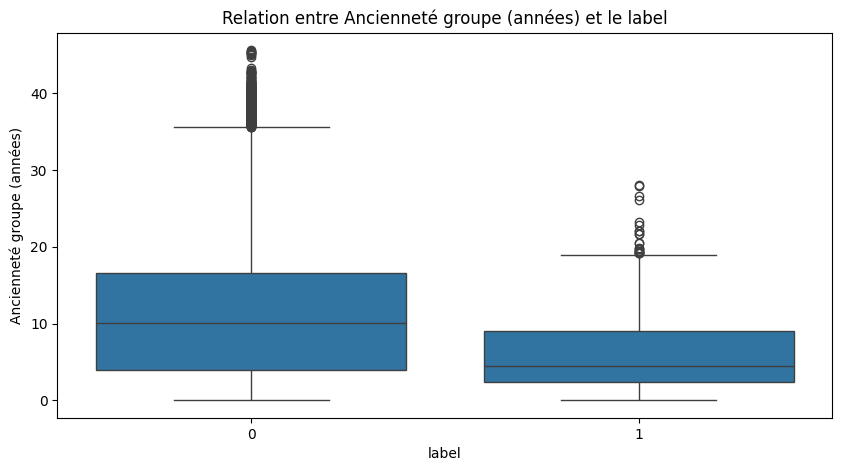

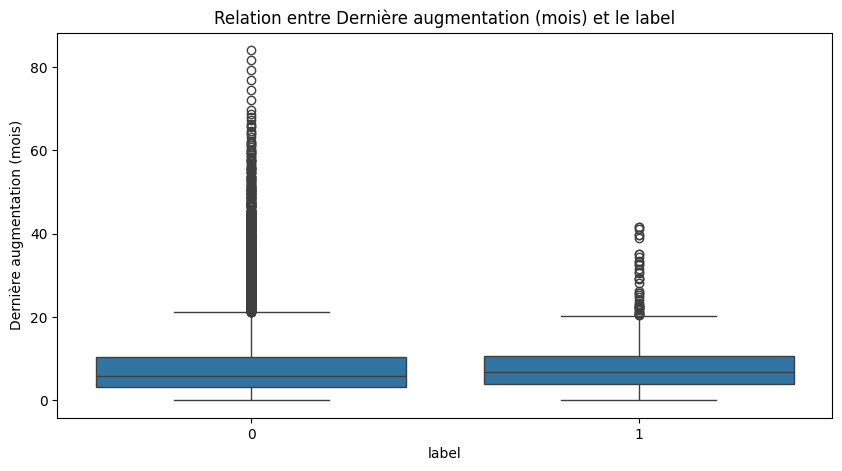

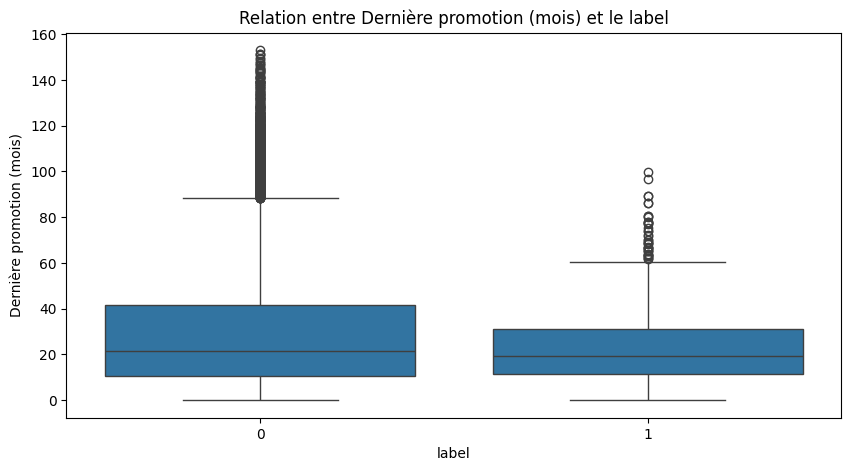

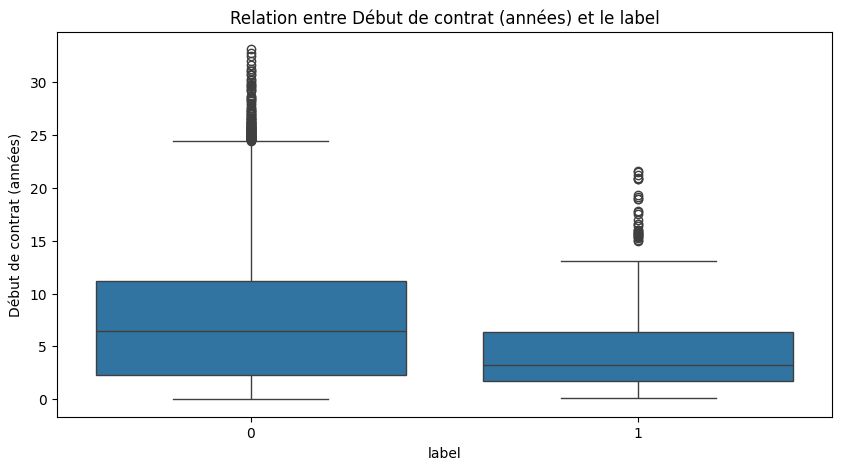

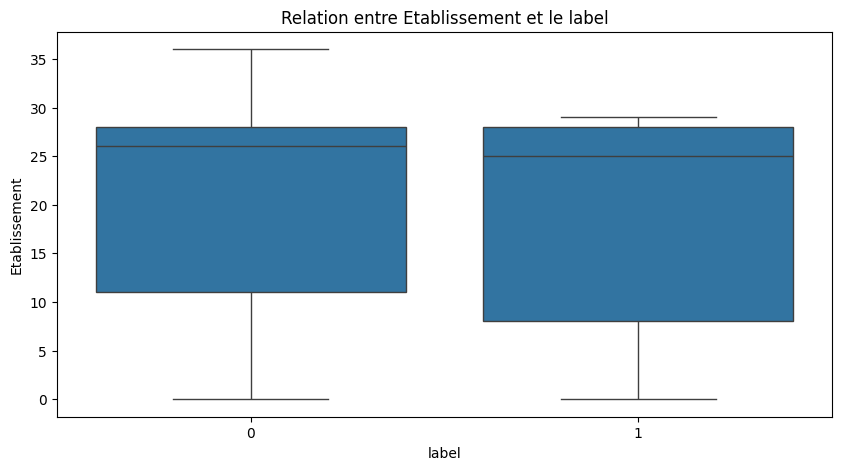

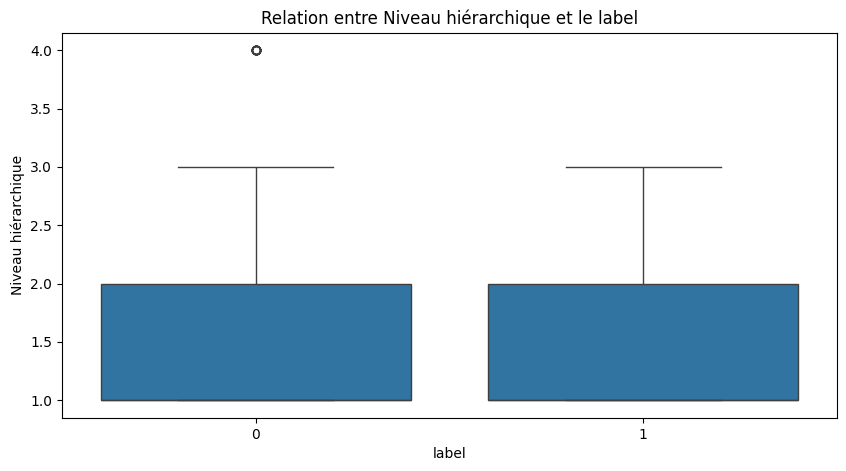

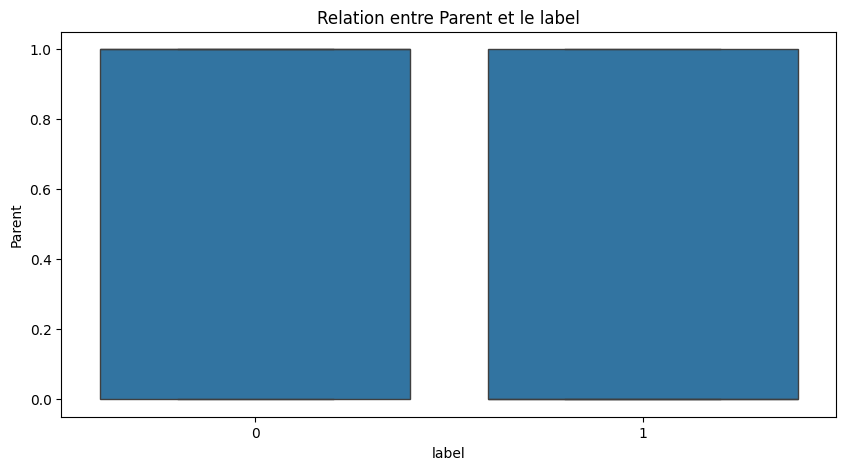

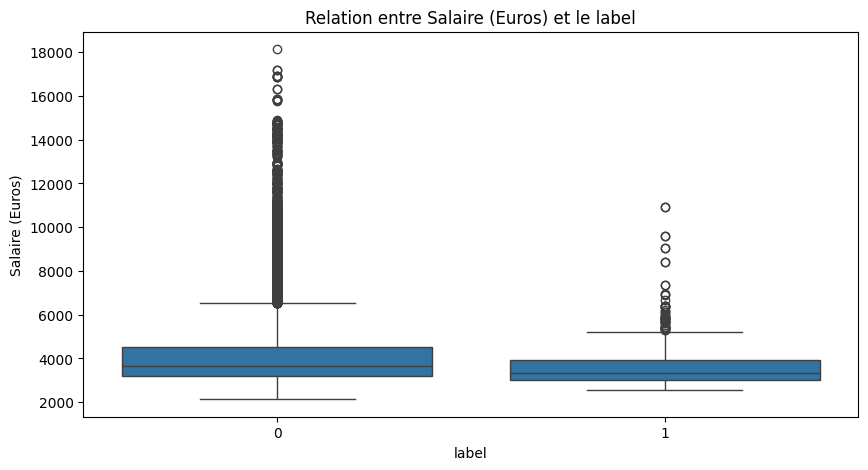

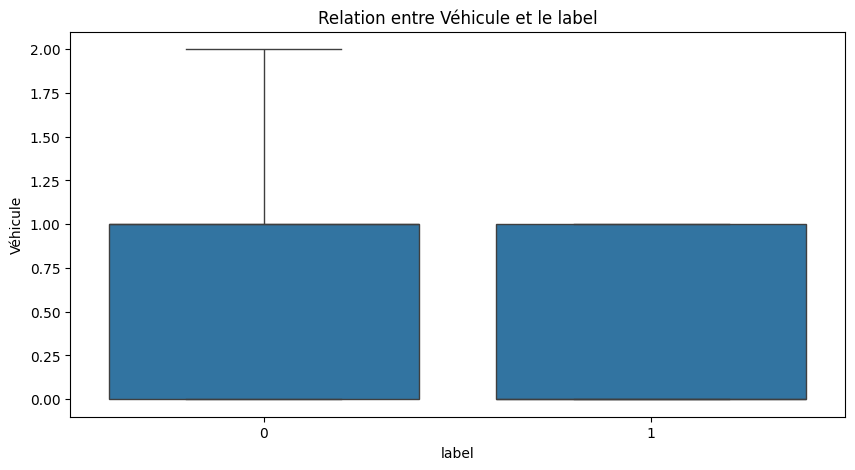

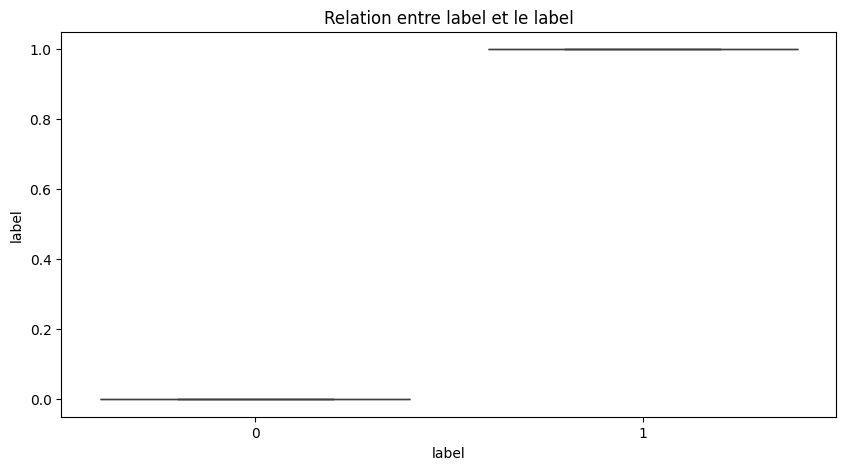

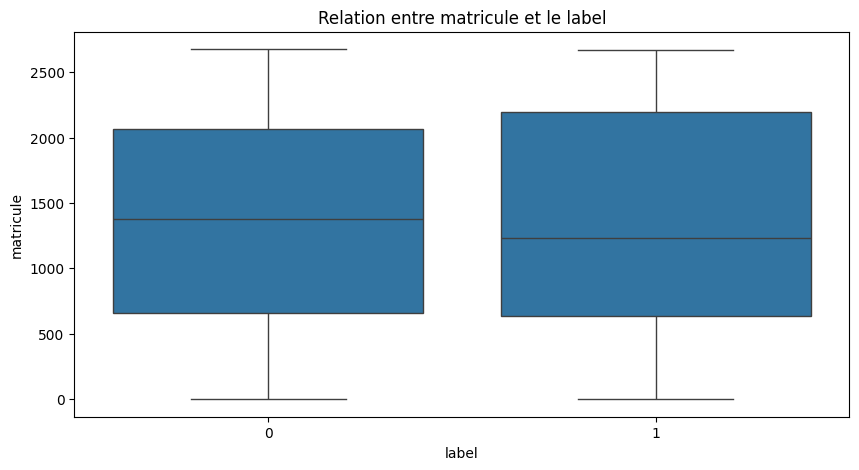

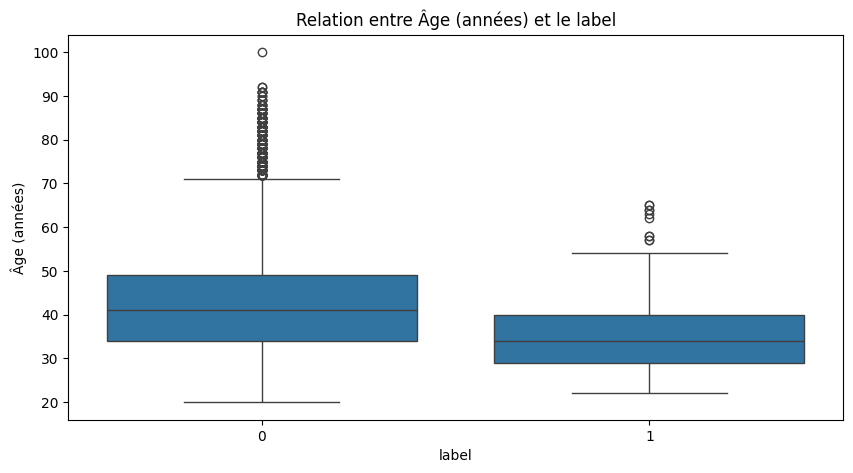

In [155]:
#objectif  voir le lien entre les différentes features et le label
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_rh, x='label', y=col)
    plt.title(f"Relation entre {col} et le label")
    plt.show()

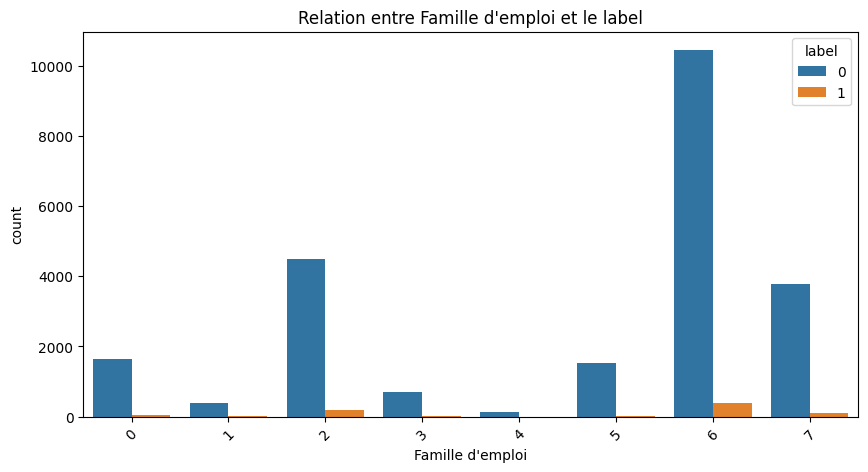

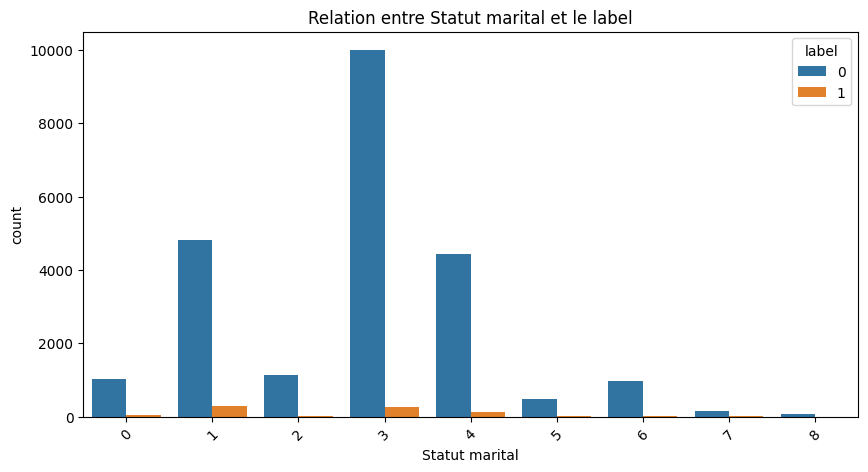

In [156]:
for col in str_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df_rh, x=col, hue='label')
    plt.title(f"Relation entre {col} et le label")
    plt.xticks(rotation=45)
    plt.show()

| Colonne                          | Type de fonction |
|----------------------------------|------------------|
| Famille d'emploi                 | f()              |
| Dernière promotion (mois)        | s()              |
| Dernière augmentation (mois)     | s()              |
| Début de contrat (années)        | s()              |
| Ancienneté groupe (années)       | l()              |
| Etablissement                    | s()              |
| Âge (années)                     | l()              |
| Parent                           | f()              |
| Niveau hiérarchique              | f()              |
| Salaire (Euros)                  | s()              |
| Statut marital                   | f()              |
| Véhicule                         | f()              |
| matricule                        | s()              |

In [157]:
df_rh.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

In [158]:
#donc on a 
from pygam import LogisticGAM, s, f, l

gam = LogisticGAM(
    f(0) +      # Famille d'emploi
    s(1) +      # Dernière promotion
    s(2) +      # Dernière augmentation
    s(3) +      # Début de contrat
    l(4) +      # Ancienneté groupe
    s(5) +      # Etablissement
    l(6) +      # Âge
    f(7) +      # Parent
    f(8) +      # Niveau hiérarchique
    s(9) +      # Salaire
    f(10) +     # Statut marital
    f(11) +     # Véhicule
    s(12)       # matricule 
).gridsearch(X_train.values, y_train.values)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:04 ETA:   0:00:45
 18% (2 of 11) |####                     | Elapsed Time: 0:00:06 ETA:   0:00:28
 27% (3 of 11) |######                   | Elapsed Time: 0:00:08 ETA:   0:00:21
 36% (4 of 11) |#########                | Elapsed Time: 0:00:09 ETA:   0:00:17
 45% (5 of 11) |###########              | Elapsed Time: 0:00:11 ETA:   0:00:14
 54% (6 of 11) |#############            | Elapsed Time: 0:00:13 ETA:   0:00:11
 63% (7 of 11) |###############          | Elapsed Time: 0:00:15 ETA:   0:00:08
 72% (8 of 11) |##################       | Elapsed Time: 0:00:17 ETA:   0:00:06
 81% (9 of 11) |####################     | Elapsed Time: 0:00:18 ETA:   0:00:04
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:20 ETA:   0:00:02
100% (11 of 11) |########################| Elapsed Time: 0:00:22 Time:  0:00:22


In [159]:
gam.accuracy(X_test.values, y_test.values)

np.float64(0.9683570829840737)

In [160]:

gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     28.1008
Link Function:                        LogitLink Log Likelihood:                                 -2422.3559
Number of Samples:                        19085 AIC:                                             4900.9134
                                                AICc:                                            4901.0053
                                                UBRE:                                                2.258
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.0961
Feature Function                  Lam

C:\Users\rapha\AppData\Local\Temp\ipykernel_15772\1761020682.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4621
           1       0.00      0.00      0.00       151

    accuracy                           0.97      4772
   macro avg       0.48      0.50      0.49      4772
weighted avg       0.94      0.97      0.95      4772



c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

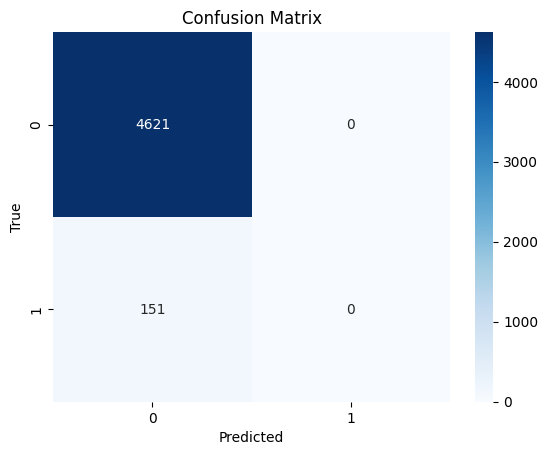

In [161]:
gam_predictions = gam.predict(X_test.values)
print(classification_report(y_test, gam_predictions))
plot_confusion_matrix(y_test, gam_predictions)

On voit que c'est la pire classification le modèle met tout en 0 le modèle a l'air très touché par le déséquillibre du dataset.

je vais le laisser pour la suite car il est équitable car il prédit toujours la classe majoritaire (label = 0) et jamais la classe minoritaire (label = 1) ce qui est logique vu le déséquilibre du dataset. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

## Evaluation de l'équité du modèle

Le gan est équitable il ne sert à rien d'alller plus loin car il prédit toujours 0

In [162]:
print(df_rh.columns)

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')


In [163]:

y_pred_xgb = grid_xgb.predict(X_test)
y_pred_lr = grid_lr.predict(X_test)

predictions = {
    'XGBoost': y_pred_xgb,
    'Logistic Regression': y_pred_lr,
}


def compute_fairness_metrics(y_true, y_pred, groups, group_name):
    """Calcule FPR, FNR, Disparate Impact par sous-groupe."""
    results = []
    overall_positive_rate = y_pred.mean()

    for group in sorted(groups.unique()):
        mask = groups == group
        y_t = y_true[mask]
        y_p = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        positive_rate = y_p.mean()
        di = positive_rate / overall_positive_rate if overall_positive_rate > 0 else 0

        results.append({
            'Groupe': f"{group_name}={group}",
            'N': mask.sum(),
            'FPR': round(fpr, 4),
            'FNR': round(fnr, 4),
            'Taux prédiction positive': round(positive_rate, 4),
            'Disparate Impact': round(di, 4)
        })

    return pd.DataFrame(results)


age_groups = pd.cut(X_test['Âge (années)'], bins=[0, 30, 40, 50, 100],
                    labels=['<30', '30-40', '40-50', '50+'])
parent_groups = X_test['Parent']
marital_groups = X_test['Statut marital']

sensitive_attributes = {
    'Âge': age_groups,
    'Parent': parent_groups,
    'Statut marital': marital_groups
}


for model_name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for attr_name, groups in sensitive_attributes.items():
        print(f"\n--- FPR / FNR / Disparate Impact par {attr_name} ---")
        df = compute_fairness_metrics(y_test.values, y_pred, groups, attr_name)
        print(df.to_string(index=False))


print(f"\n{'='*60}")
print("  RÉSUMÉ - Disparate Impact (seuil: 0.8 - 1.25)")
print(f"{'='*60}")

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    for attr_name, groups in sensitive_attributes.items():
        df = compute_fairness_metrics(y_test.values, y_pred, groups, attr_name)
        di_range = f"[{df['Disparate Impact'].min():.3f} - {df['Disparate Impact'].max():.3f}]"
        equitable = "Équitable" if df['Disparate Impact'].between(0.8, 1.25).all() else "Non équitable"
        print(f"  {attr_name} -> DI {di_range} -> {equitable}")


  XGBoost

--- FPR / FNR / Disparate Impact par Âge ---
   Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Âge=30-40 1568 0.0370 0.6250                    0.0491            1.5022
Âge=40-50 1516 0.0054 0.8537                    0.0092            0.2825
  Âge=50+  947 0.0011 0.7500                    0.0032            0.0969
  Âge=<30  741 0.0633 0.6087                    0.0837            2.5595

--- FPR / FNR / Disparate Impact par Parent ---
  Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Parent=0 1314 0.0582 0.6316                    0.0761            2.3280
Parent=1 3458 0.0109 0.7467                    0.0162            0.4954

--- FPR / FNR / Disparate Impact par Statut marital ---
          Groupe    N    FPR    FNR  Taux prédiction positive  Disparate Impact
Statut marital=0  201 0.0051 0.6667                    0.0149            0.4566
Statut marital=1 1016 0.0572 0.6296                    0.0738            2.2581
Statut marital=2

### Analyse de l'équité des modèles

**Aucun des deux modèles n'est équitable.** Les Disparate Impact dépassent largement les seuils acceptables (0.8 - 1.25) sur tous les attributs sensibles.

**Par âge**, le biais est flagrant pour les deux modèles. Les jeunes (<30 ans) sont fortement sur-ciblés : DI de 2.56 pour XGBoost et 4.15 pour la Logistic Regression, ce qui signifie qu'ils sont respectivement 2.5x et 4x plus susceptibles de recevoir une prédiction positive que la moyenne. À l'inverse, les 50+ sont quasiment ignorés (DI proche de 0), avec un FNR de 100% pour la Logistic Regression — aucun positif détecté dans cette tranche.

**Par statut parental**, les non-parents (Parent=0) sont massivement sur-ciblés, surtout par la Logistic Regression (DI=3.08, FPR=66%) qui prédit à tort comme positifs deux tiers des non-parents négatifs. Les parents sont sous-détectés (FNR élevé de 75-88%).

**Par statut marital**, les écarts sont tout aussi importants. Le statut 1 est systématiquement sur-ciblé (DI > 2 pour les deux modèles), tandis que plusieurs statuts ont un DI à 0, indiquant une absence totale de prédiction positive.

**Trade-off performance/équité** : la Logistic Regression présente des biais nettement plus extrêmes que XGBoost (DI allant jusqu'à 4.15 contre 2.56). XGBoost distribue ses erreurs de manière un peu plus homogène, mais reste loin de l'équité. Cela s'explique probablement par le fait que l'âge, le statut parental et le statut marital sont fortement corrélés avec la variable cible, et les modèles exploitent ces corrélations sans contrainte d'équité.

**Conclusion** : si ce modèle devait être déployé en production (par exemple pour prédire un départ de l'entreprise), il faudrait envisager des techniques de mitigation de biais (contraintes d'équité, post-processing des seuils par groupe, ou retrait des variables proxy) pour éviter une discrimination systématique envers les jeunes employés sans enfants.

# 4. Explication post-hoc

In [164]:

best_lr = grid_lr.best_estimator_
X_tr = best_lr[:-1].transform(X_train)
feat_names = best_lr[:-1].get_feature_names_out()
lr_model = best_lr[-1]

probas = lr_model.predict_proba(np.array(X_tr))[:, 1]
XtWX = np.array(X_tr).T @ (np.array(X_tr) * (probas * (1 - probas))[:, np.newaxis])
se = np.sqrt(np.diag(np.linalg.inv(XtWX)))


coefs = lr_model.coef_[0]
t_stats = coefs / se
lr_stats = pd.DataFrame({
    'Feature': feat_names, 'Coef': coefs, 'SE': se, 't': t_stats
}).sort_values('t', key=abs, ascending=False)


best_xgb = grid_xgb.best_estimator_
feat_names_xgb = best_xgb[:-1].get_feature_names_out()
importances = best_xgb[-1].feature_importances_
xgb_imp = pd.DataFrame({
    'Feature': feat_names_xgb, 'Importance': importances
}).sort_values('Importance', ascending=False)

display(lr_stats)
display(xgb_imp)

,Feature,Coef,SE,t
7,Parent,-0.201396,0.019233,-10.471397
4,Ancienneté groupe (années),-0.731437,0.072277,-10.119961
1,Dernière promotion (mois),0.240982,0.028647,8.412021
2,Dernière augmentation (mois),0.156294,0.020442,7.645765
6,Âge (années),-0.515311,0.107911,-4.775321
12,matricule,0.058372,0.017571,3.322044
0,Famille d'emploi,0.052468,0.017170,3.055762
11,Véhicule,0.082609,0.035686,2.314900
9,Salaire (Euros),0.137746,0.061975,2.222593
10,Statut marital,-0.037980,0.019270,-1.970951


,Feature,Importance
7,Parent,0.145910
4,Ancienneté groupe (années),0.116576
6,Âge (années),0.100029
0,Famille d'emploi,0.073064
5,Etablissement,0.070714
10,Statut marital,0.068605
12,matricule,0.068414
8,Niveau hiérarchique,0.065557
9,Salaire (Euros),0.064451
3,Début de contrat (années),0.064138


#### Analyse rapide du modèle

Les résultats montrent que plusieurs variables ont un impact significatif sur la cible.

- **Effets négatifs forts** :  
  L’**ancienneté**, l’**âge** et le fait d’être **parent** sont associés à une baisse de la variable cible. L’ancienneté est le facteur le plus marqué.

- **Effets positifs** :  
  Le temps depuis la **dernière promotion** et la **dernière augmentation** a un effet positif significatif, ce qui peut nécessiter une vérification métier (interprétation du sens de la variable).

- **Variables modérément influentes** :  
  Le **salaire**, la **famille d’emploi** et la possession d’un **véhicule** ont un impact positif mais plus faible.

- **Peu significatives** :  
  Le **niveau hiérarchique**, l’**établissement** et le **début de contrat** semblent peu explicatifs.

#### Points de vigilance

- La variable **matricule** est probablement une fuite de données.  
- Certaines variables (**âge, statut parental, statut marital**) peuvent introduire des biais.  
- Des écarts entre coefficients et importances suggèrent des effets non linéaires.
- on peut supprimer les colones  peu significatives et la colone matricule pour éviter les fuites de données et les biais.

#### Conclusion

Le modèle est globalement robuste mais nécessite un nettoyage (variables sensibles et fuite) 

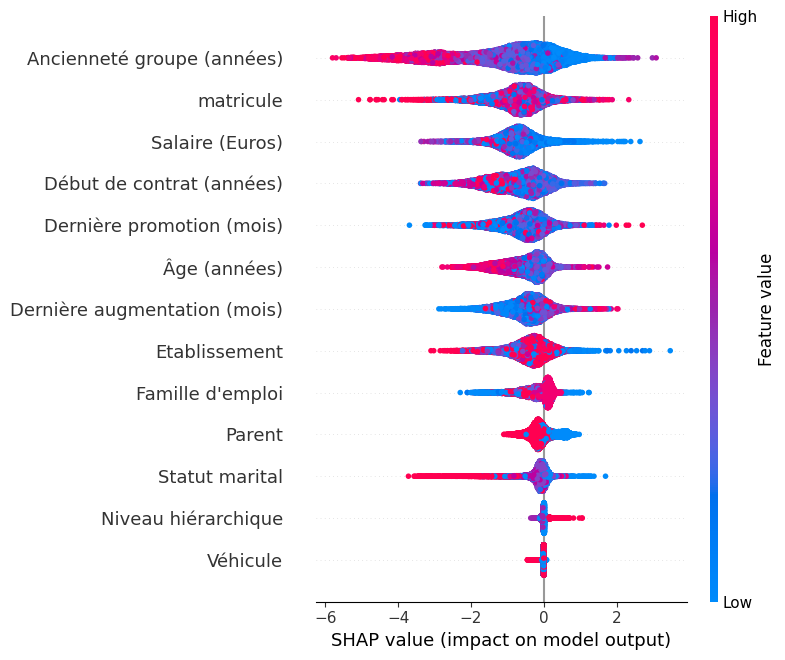

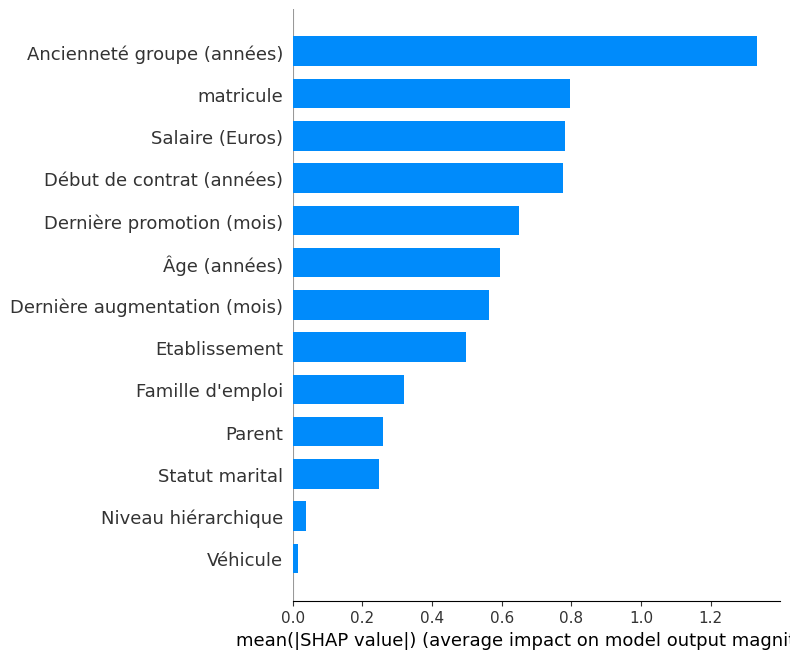

In [165]:
import shap
best_xgb = grid_xgb.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)



L’analyse SHAP met en évidence les variables les plus influentes dans les prédictions du modèle.

- **Variable dominante** :  
  L’**ancienneté groupe** est de loin le facteur le plus impactant, indiquant un rôle central dans la décision du modèle.

- **Variables importantes** :  
  Le **matricule**, le **salaire** et le **début de contrat** ont un poids élevé.  
  **Atttention** : La présence du **matricule** confirme un risque de fuite de données ce que l'on a pu voir dans l'analyse précédente.

- **Facteurs intermédiaires** :  
  La **dernière promotion**, l’**âge** et la **dernière augmentation** contribuent de manière significative mais moindre.

- **Faible influence** :  
  Le **niveau hiérarchique** et le **véhicule** ont un impact quasi nul.

#### Points clés

- Le modèle repose fortement sur des variables liées à l’**ancienneté** et au **parcours professionnel**.  
- Des variables sensibles (**âge, parent, statut marital**) restent présentes mais peu dominantes.  
- Cohérence globale avec la régression, mais SHAP révèle mieux les effets non linéaires.

#### Conclusion

Le modèle XGBoost est principalement piloté par l’ancienneté et l’historique RH, mais nécessite un nettoyage (notamment suppression du matricule) pour éviter les biais et améliorer la robustesse.

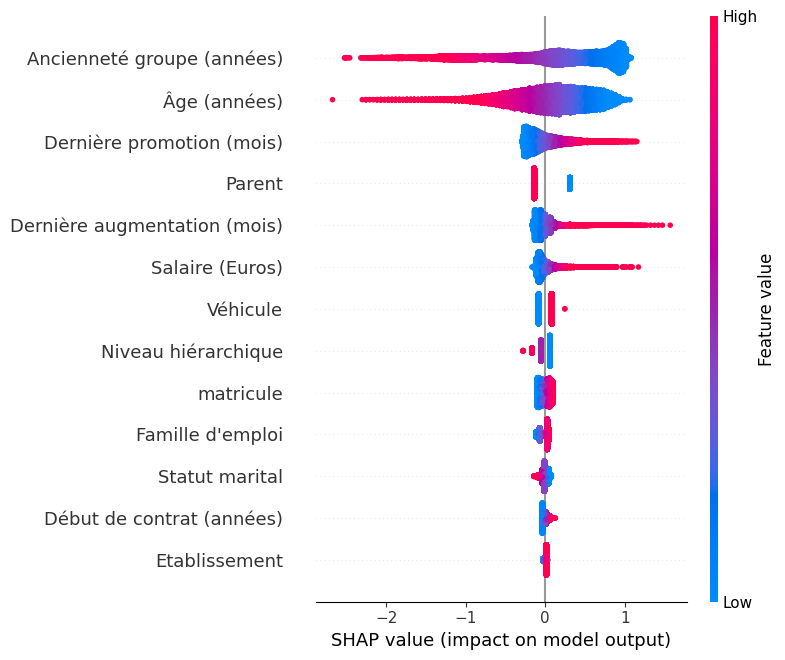

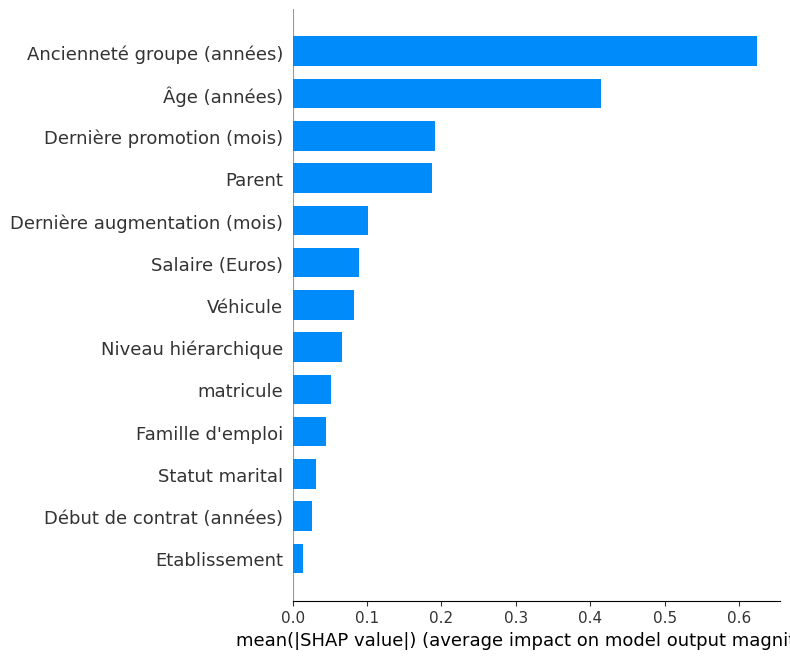

In [166]:


best_lr = grid_lr.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()

X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)

explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)

# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar", max_display=15, show=True)

#### Analyse SHAP – Régression Logistique

L’interprétation SHAP confirme les résultats du modèle linéaire avec une hiérarchie claire des variables.

- **Facteurs dominants** :  
  L’**ancienneté groupe** reste la variable la plus influente, suivie de l’**âge**, ce qui souligne un effet fort lié au temps et au cycle de carrière.

- **Variables importantes** :  
  La **dernière promotion** et le statut **parent** jouent un rôle notable dans les prédictions.

- **Impact modéré** :  
  La **dernière augmentation**, le **salaire** et le **véhicule** ont un effet plus limité.

- **Faible influence** :  
  Le **matricule**, la **famille d’emploi**, le **statut marital**, le **début de contrat** et l’**établissement** contribuent peu au modèle.

#### Points clés

- Cohérence forte avec les coefficients de la régression → modèle stable et interprétable.  
- Les variables liées à l’**ancienneté** et à l’**âge** dominent clairement.  
- Le **matricule** a ici un impact faible, ce qui réduit le risque de fuite comparé à XGBoost.

#### Conclusion

La régression logistique met en évidence un modèle plus simple et robuste, dominé par des effets linéaires liés à l’ancienneté et à l’âge, avec peu de dépendance à des variables parasites.

# 5. Apprentissage automatique

On va faire un entrainnnement où on enlève les colonnes qui font fuire de l'information et celles qui sont peu significatives pour voir si on peut améliorer les performances du modèle et réduire les biais.

Dans un second temps on va enlever les colones sensibles pour voir si on peut réduire les biais du modèle.

## Etape 1: En enlevant les fuites de données et les colones peu significatives

### XGBoost

In [167]:
df_rh_xgb=df_rh.drop(columns=['matricule', 'Niveau hiérarchique', 'Véhicule'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [168]:


#nouvel entrainnement du modèle xgboost
xgb_clf_new = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)
pipeline_xgb_new = make_pipeline(pipeline_preprocessing, xgb_clf_new)
grid_xgb_new = GridSearchCV(
    pipeline_xgb_new, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb_new.fit(X_train, y_train)
print("Best parameters:", grid_xgb_new.best_params_)
print("Best F1 score:", grid_xgb_new.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.22729783584431082


              precision    recall  f1-score   support

           0       0.98      0.94      0.96      4621
           1       0.17      0.38      0.23       151

    accuracy                           0.92      4772
   macro avg       0.57      0.66      0.60      4772
weighted avg       0.95      0.92      0.93      4772



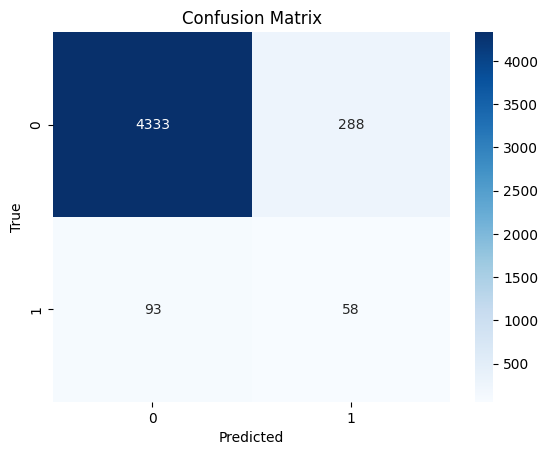

In [169]:
# predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_xgb_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)


On voit que l'on a une prédiction un peu moins bonne de très peu mais c'est normal vu que l'on a enlevé des colones qui étaient importantes pour la prédiction du label puisqu'elle faisait de la fuite de données. Cependant, le score reste très faible ce qui indique que le modèle a du mal à prédire la classe minoritaire (label = 1).

### Post-hoc xgb

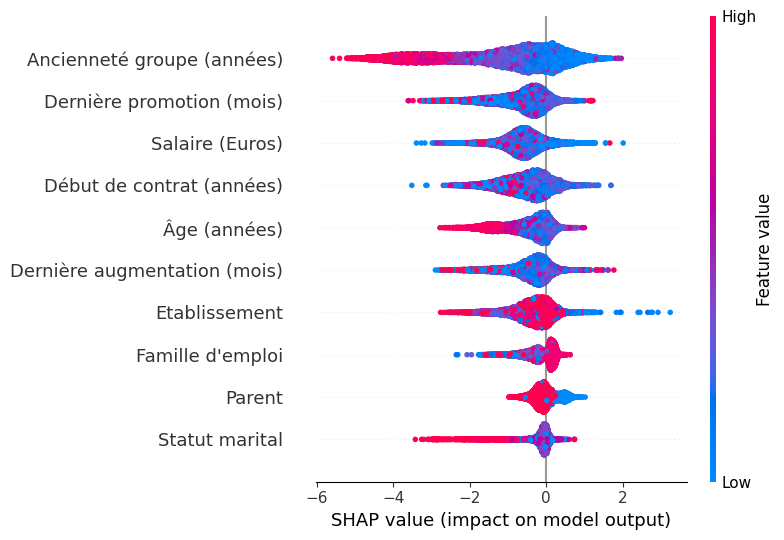

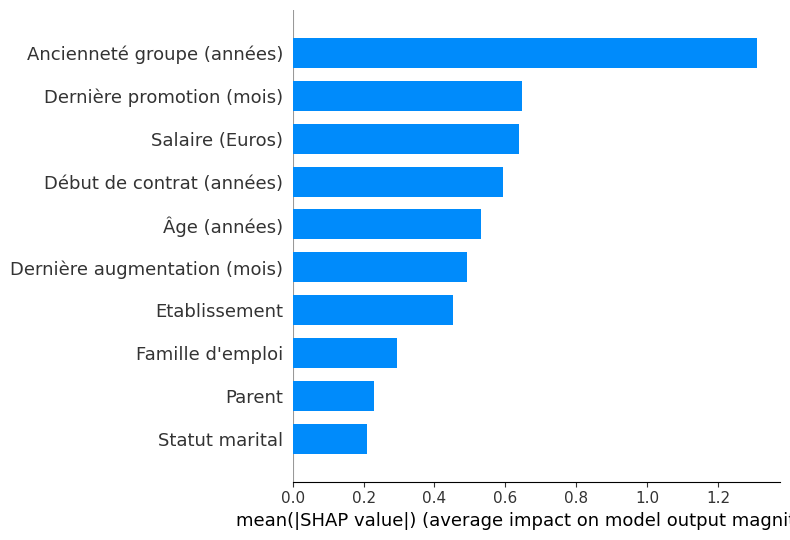

In [170]:

best_xgb = grid_xgb_new.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)

# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)

On voit que l'anciennneté dans le groupe reprend une forte importance ainsi que la dernière promotion aussi et le salaire ce qui est beaucoup plus logique que le matricule qui faisait de la fuite de données. 
Et on voit que plus ces valeurs sont élevés plus les personnes ont tendance à rester dans l'entreprise (label = 0) ce qui est logique (commment ça les personnes loyale et bien payé reste plus longtemeps dans l'entreprise ? Incroyable !)

Chaque colone a un impact même si certaines ont un impact plus fort que d'autres. Cependant on remarque que les variables biaisé donc le statut parental et le statut marital ont un impact plus faible donc les supprimer parait une bonne idée la seule variable sensible qui a un poid important est l'âge. On verra si on peut faire quelque chose.

### Logistic Regression

In [171]:

df_rh_lr=df_rh.drop(columns=['matricule', "Famille d'emploi", 'Statut marital', 'Début de contrat (années)', 'Etablissement'])
X = df_rh_lr.drop(columns=['label'])
y = df_rh_lr['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [172]:

#nouvel entrainnement du modèle de régression logistique
lr_clf_new = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)
pipeline_lr_new = make_pipeline(pipeline_preprocessing, lr_clf_new)
grid_lr_new = GridSearchCV(
    pipeline_lr_new, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr_new.fit(X_train, y_train)
print("Best parameters:", grid_lr_new.best_params_)
print("Best F1 score:", grid_lr_new.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.12458082385164886


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.79      0.88      4621
           1       0.07      0.50      0.13       151

    accuracy                           0.78      4772
   macro avg       0.53      0.64      0.50      4772
weighted avg       0.95      0.78      0.85      4772



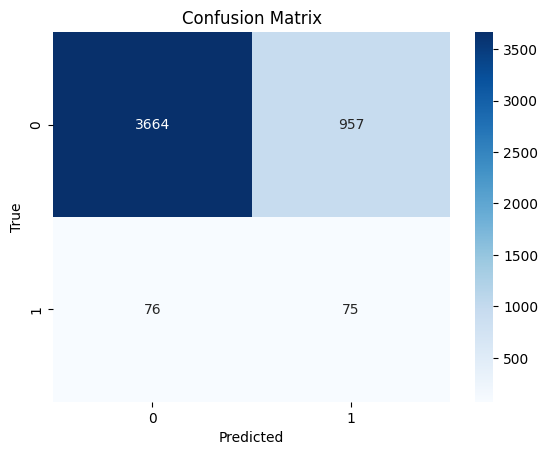

In [173]:
#predictions des 2 modèles sur X_test
y_pred_lr_new = grid_lr_new.predict(X_test)
print(classification_report(y_test, y_pred_lr_new))
plot_confusion_matrix(y_test, y_pred_lr_new)

Le score est bien moins bon qu'avec XGBoosst mais cela est normal car la régression logistique s'appuyait sur des colones que l'on a enlevé

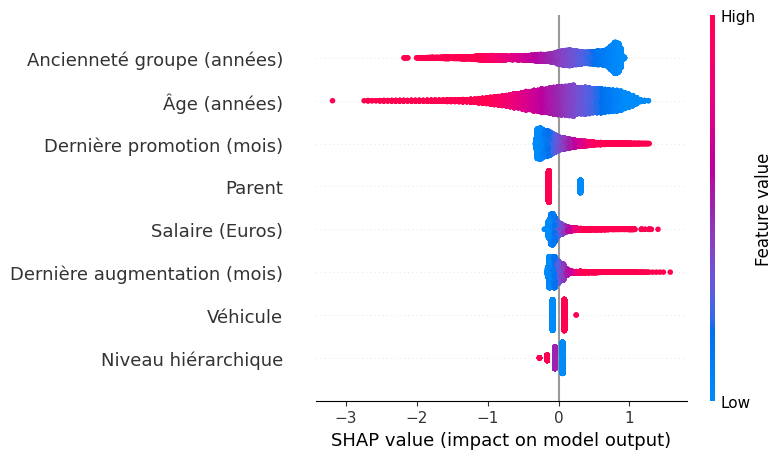

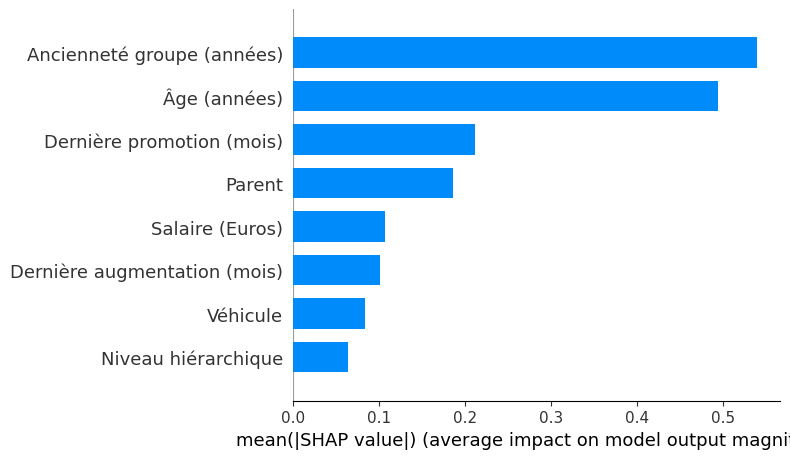

In [174]:
#shap
best_lr = grid_lr_new.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()
X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)
explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)

# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15,
                    show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar",
                    max_display=15, show=True)


On voit que les colones qui ont le plus d'importance sont l'ancienneté dans le groupe et l'âge ce qui est logique vu que ce sont les deux colones les plus corrélées avec le label. Cependant, on voit que l'âge etait biaisé mais il a quand même un poid important dans la prédiction du label ce qui est problématique. On verra si on peut faire quelque chose pour réduire ce biais.

## Etape 2: En enlevant les colones sensibles

### XGboost

In [175]:
df_rh_xgb.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Salaire (Euros)', 'Statut marital', 'label'],
      dtype='str')

In [176]:

df_rh_xgb=df_rh_xgb.drop(columns=['Âge (années)', 'Parent', 'Statut marital'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#nouvel entrainnement du modèle de xgboost
xgb_clf_new = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(1 - y.mean()) / y.mean()
)
pipeline_xgb_new = make_pipeline(pipeline_preprocessing, xgb_clf_new)
grid_xgb_new = GridSearchCV(
    pipeline_xgb_new, param_grid_xgb, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb_new.fit(X_train, y_train)
print("Best parameters:", grid_xgb_new.best_params_)
print("Best F1 score:", grid_xgb_new.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'xgbclassifier__learning_rate': 0.3, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__scale_pos_weight': 50}
Best F1 score: 0.19578363047533295


              precision    recall  f1-score   support

           0       0.98      0.95      0.96      4621
           1       0.15      0.30      0.20       151

    accuracy                           0.93      4772
   macro avg       0.57      0.62      0.58      4772
weighted avg       0.95      0.93      0.94      4772



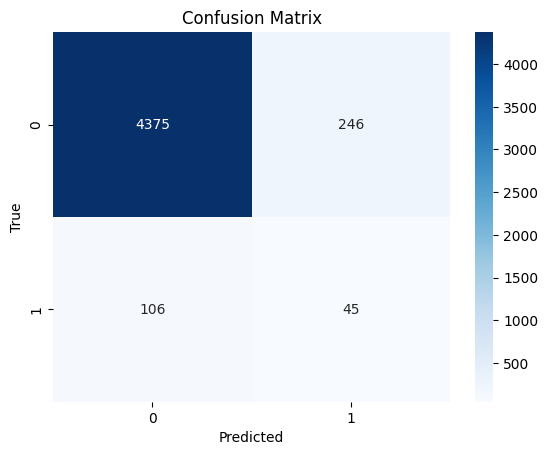

In [177]:
#predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_xgb_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)

C'est mieux la classe 1 est un peu mieux prédite.

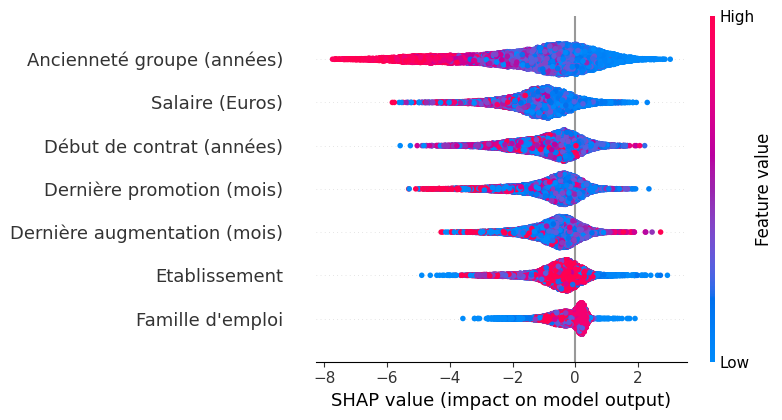

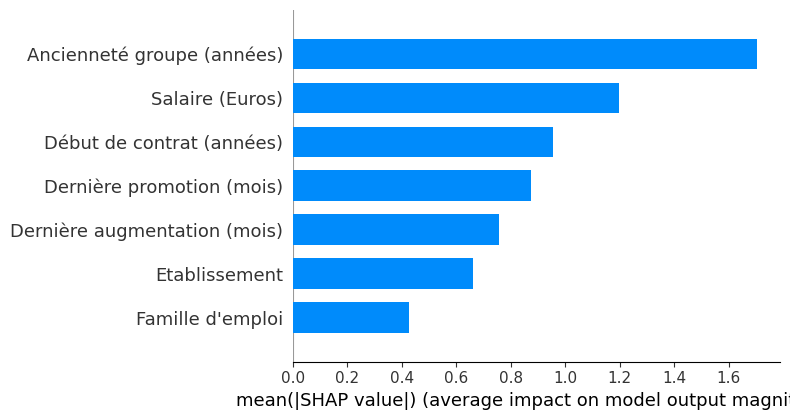

In [178]:
#shap xgb
best_xgb = grid_xgb_new.best_estimator_
X_train_transformed = best_xgb[:-1].transform(X_train)
feature_names = best_xgb[:-1].get_feature_names_out()
X_train_df= pd.DataFrame(X_train_transformed, columns=feature_names)
explainer_xgb = shap.TreeExplainer(best_xgb[-1])
shap_values_xgb = explainer_xgb.shap_values(X_train_df)         

# Summary plot
shap.summary_plot(shap_values_xgb, X_train_df, max_display=15, show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_xgb, X_train_df, plot_type="bar", max_display=15, show=True)

### Logistic Regression

In [183]:
df_rh_lr=df_rh_lr.drop(columns=['Âge (années)', 'Parent'])
X = df_rh_xgb.drop(columns=['label'])
y = df_rh_xgb['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
#nouvel entrainnement du modèle de régression logistique
lr_clf_new = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)
pipeline_lr_new = make_pipeline(pipeline_preprocessing, lr_clf_new)
grid_lr_new = GridSearchCV(
    pipeline_lr_new, param_grid_lr, cv=cv,
    scoring='f1', n_jobs=-1, verbose=1
)
grid_lr_new.fit(X_train, y_train)
print("Best parameters:", grid_lr_new.best_params_)
print("Best F1 score:", grid_lr_new.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'logisticregression__C': 0.1, 'logisticregression__class_weight': {0: 1, 1: 20}, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Best F1 score: 0.11046662290076152


c:\Users\rapha\OneDrive - De Vinci\centrale_s3\rexia\rexia_projet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.74      0.84      4621
           1       0.06      0.53      0.11       151

    accuracy                           0.73      4772
   macro avg       0.52      0.63      0.48      4772
weighted avg       0.95      0.73      0.82      4772



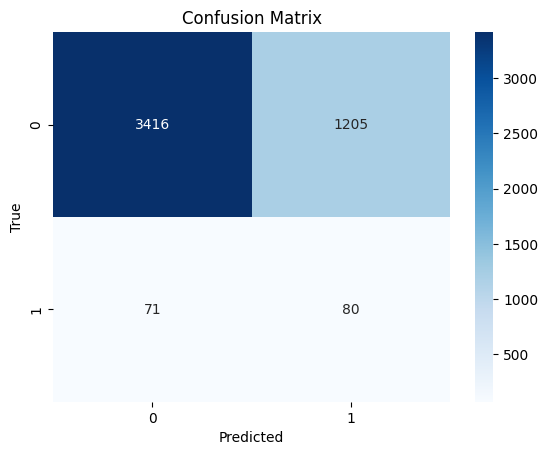

In [184]:
#predictions des 2 modèles sur X_test
y_pred_xgb_new = grid_lr_new.predict(X_test)
print(classification_report(y_test, y_pred_xgb_new))
plot_confusion_matrix(y_test, y_pred_xgb_new)


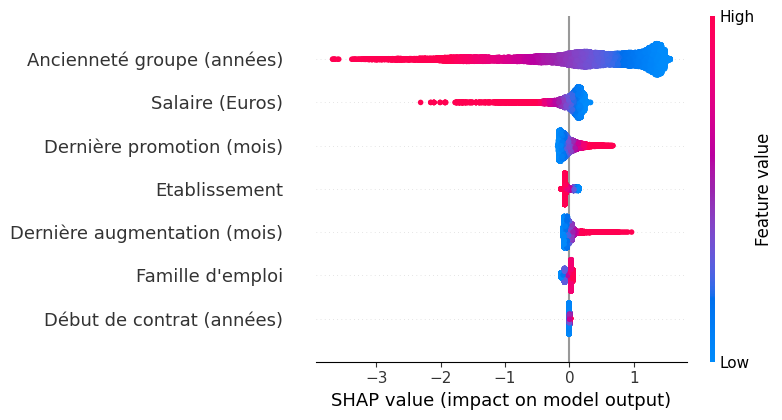

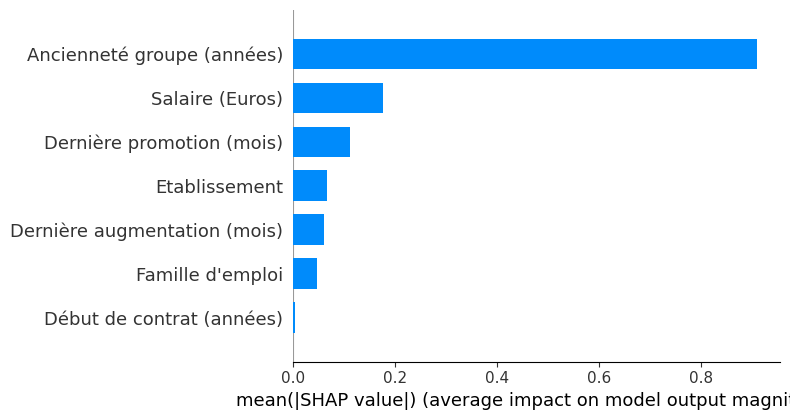

In [185]:
#shap
best_lr = grid_lr_new.best_estimator_
X_train_transformed_lr = best_lr[:-1].transform(X_train)
feature_names_lr = best_lr[:-1].get_feature_names_out()
X_train_df_lr = pd.DataFrame(X_train_transformed_lr, columns=feature_names_lr)
explainer_lr = shap.LinearExplainer(best_lr[-1], X_train_df_lr)
shap_values_lr = explainer_lr.shap_values(X_train_df_lr)
# Summary plot
shap.summary_plot(shap_values_lr, X_train_df_lr, max_display=15,
                    show=True)
# Bar plot (importance moyenne)
shap.summary_plot(shap_values_lr, X_train_df_lr, plot_type="bar",
                    max_display=15, show=True)


# 6. Conclusion

Des risques sont visible dans l'utilisation de ce dataset premièrement techniquement le datset est très déséquilibré ce qui rend la prédiction de la classe minoritaire très difficile. De plus, il y a des variables qui font de la fuite de données comme le matricule ce qui rend le modèle peu robuste et peu généralisable car des données de test peuvent être devinées à partir du train. Enfin des variables sont biaisés comme l'âge, le statut parental et le statut marital ce qui rend le modèle potentiellement discriminatoire envers certaines catégories de personnes. Il serait donc nécessaire de faire du prétraitement pour enlever les variables de fuite de données et les variables biaisées pour améliorer la robustesse et l'équité du modèle. De plus, il serait intéressant d'essayer des techniques de rééquilibrage pour améliorer la prédiction de la classe minoritaire. Au final après avoir traité les données on voit que l'ancienneté et le salaire sont les variables à plus surveiller pour prédire le label car plus elles sont élevées plus les personnes ont tendance à rester dans l'entreprise (label = =0). 

Il faut voir que ces points sont réalisé grâce à l'analyse des données mais aussi avec des méthode post-hoc (comme shap)qui ont des limites comme le fait qu'elles explique la logique du modèle mais no pas forcément la vérité exacte. De plus le modèle ayant des difficultés à prédire la classe minoritaire, il est possible que les explications soient biaisées par le fait que le modèle se concentre principalement sur la classe majoritaire.